<h1 style="text-align: center;">[Your Project Title]</h1>
<h3 style="text-align: center;">[Your Name]</h3>

---

## **Section 0. Setup**

> 🎯 *Tujuan:* Menyiapkan environment kerja (import library, konfigurasi global) supaya proses selanjutnya konsisten dan reproducible.

**0.1 Import Library**

> 🎯 *Tujuan:* Memuat semua library yang dibutuhkan di satu tempat di awal, supaya dependency notebook mudah dilacak.

In [ ]:
# import library dasar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# tambahkan import lain sesuai kebutuhan (sklearn, dll) di sini
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import FunctionTransformer, RobustScaler, OneHotEncoder, PowerTransformer

from sklearn.feature_selection import SelectFromModel

from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier, PassiveAggressiveClassifier
from sklearn.svm import LinearSVC, SVC

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import pickle

**0.2 Global Configuration**

> 🎯 *Tujuan:* Menetapkan parameter global seperti random_state di satu tempat, supaya semua proses (split, model, CV) memakai nilai yang sama.

> 📌 **Catatan untuk Peserta:** Selalu set `RANDOM_STATE` di satu tempat dan pakai variabel yang sama di semua proses (train_test_split, model, cross-validation). Ini membuat hasil eksperimenmu **reproducible** — orang lain (atau kamu sendiri, minggu depan) bisa menjalankan ulang notebook dan dapat hasil yang sama persis.

In [64]:
RANDOM_STATE = 42
pd.set_option('display.max_columns', None)

df =  pd.read_csv(r"..\\data\\raw\\data_bank_marketing_campaign.csv")

## **Section 1. Business Understanding**

> 🎯 *Tujuan:* Menerjemahkan masalah bisnis menjadi masalah yang bisa diselesaikan dengan machine learning, sebelum menyentuh data sama sekali.

**1.1 Context**

> 🎯 Bank merupakan salah satu Lembaga keuangan yang menawarkan berbagai produk kepada Masyarakat, seperti Tabungan, kredit, investasi, dan deposito berjangka (term deposit). Salah satu produk investasi yang banyak ditawarkan adalah deposito berjangka, yaitu simpanan yang hanya dapat cair stelah jangka waktu tertentu dengan memberi hasil berupa bunga tetap.
Dalam industri perbankan yang semakin kompetitif, mempertahankan nasabah lama sekaligus memperoleh nasabah baru menjadi tantangan utama. Salah satu strategi yang umum dilakukan ialah marketing campaign, yaitu kegiatan promosi yang dilakukan melalui telepon atau media komunikasi lainnya untuk menawarkan produk deposito kepada calon nasabah.
Namun, pelaksanaan marketing campaign membutuhkan biaya dan sumber daya yang cukup besar. Tidak semua calon nasabah yang dihubungi akan tertarik untuk membuka deposito. Oleh sebab itu, bank perlu mengidentifikasi pelanggan yang memiliki peluang tinggi untuk menerima penawaran sehingga marketing campaign dapat berjaalan lebih efektif dan efisien.
Melalui analisis data historis pelanggan dan aktivitas marketing campaign, Perusahaan dapat membangun model prediksi yang membantu menentukan pelanggan yang berpotensi untuk dihubungi pada kampanye berikutnya.
    
    
    Stakeholder :
- Marketing tim : Mengelola campaign serta menentukan strategi marketing email, SMS, atau digital campaign.
- Sales tim : Mengevaluasi performa campaign dan tenaga pemasaran, serta melakukan komunikasi langsung kepada calon nasabah dalam menawarkan  produk deposito
- Data science team :menyediakan insight bisnis dan mengembangkan prediksi model yang dapat mendukung keputusan bisnis 
- Executive manajemen : mengambil keputusan strategis berdasarkan hasil bisnis 



**1.2 Problem Statements**

> 🎯 *Tujuan:* Merumuskan masalah secara spesifik dan terukur, biasanya dalam bentuk pertanyaan yang bisa dijawab lewat data.

Marketing campaign yang dilakukan kepada seluruh pelanggan tanpa mempertimbangkan karakteristik masing-masing pelanggan dapat menyebabkan:
- Tingginya biaya operasional pemasaran.
- Rendahnya tingkat keberhasilan campaign.
- Waktu tenaga pemasaran terbuang untuk menghubungi pelanggan yang kemungkinan besar akan menolak penawaran.
- Peluang kehilangan calon pelanggan potensial karena strategi pemasaran kurang tepat sasaran.

Berdasarkan masalah yang dihadapi pertanyaan yang perlu dijawab ialah 
1. Karakteristik pelanggan seperti apa yang memiliki kecenderungan lebih tinggi untuk membuka deposito?
2. Faktor-faktor apa yang paling memengaruhi keputusan pelanggan untuk membuka deposito setelah menerima marketing campaign?
3. Bagaimana riwayat dan strategi marketing campaign memengaruhi tingkat keberhasilan penawaran deposito?
4. Segmen pelanggan mana yang memiliki peluang konversi tertinggi sehingga layak diprioritaskan dalam campaign berikutnya?
5. Bagaimana model yang dibuat dapat membantu memprediksi pelanggan potensial untuk meningkatkan efektivitas dan efisiensi marketing campaign?

**1.3 Goals**

> 🎯 *Tujuan:* Menetapkan target yang ingin dicapai proyek ini, sebagai turunan langsung dari problem statement di atas.

Tujuan utama proyek ini adalah membangun model machine learning yang mampu memprediksi apakah seorang pelanggan akan membuka deposito (deposit) setelah menerima penawaran marketing campaign.

Model ini diharapkan dapat membantu bank untuk:

- Mengidentifikasi pelanggan dengan peluang tinggi melakukan deposito.
- Meningkatkan conversion rate marketing campaign.
- Mengurangi biaya marketing dengan menghubungi pelanggan yang lebih berpotensial 
- Mengoptimalkan produktivitas tim marketing.
- Mendukung pengambilan keputusan berbasis data (data-driven decision making).

**1.4 Analytical Approach**

> 🎯 *Tujuan:* Menentukan pendekatan analitis/teknis (misal klasifikasi atau regresi) yang akan dipakai untuk mencapai goals.

Analytical Approach

Proyek ini menggunakan pendekatan analitis berbasis data untuk memahami faktor-faktor yang memengaruhi keberhasilan marketing campaign, mengidentifikasi segmen pelanggan potensial, serta membangun model prediksi yang dapat membantu bank menentukan pelanggan yang paling mungkin membuka deposito.

Pendekatan analisis dilakukan secara bertahap, mulai dari pemahaman bisnis, eksplorasi data, hingga pengembangan model machine learning dan penyusunan rekomendasi bisnis.

Tahapan analytical approach
1. Business understanding

Pada tahap awal, dilakukan pemahaman terhadap tujuan bisnis bank, yaitu meningkatkan efektivitas marketing campaign untuk produk deposito. Tahap ini juga mencakup identifikasi permasalahan bisnis, stakeholder yang terlibat, serta indikator keberhasilan proyek.

2. Data understanding

Dataset dianalisis untuk memahami struktur data, tipe variabel, distribusi data, serta hubungan antara fitur pelanggan, riwayat campaign, dan target deposit.

3. Exploratory data analysis (EDA)

EDA dilakukan untuk menjawab pertanyaan bisnis, seperti:

- Karakteristik pelanggan yang cenderung membuka deposito.

- Pengaruh usia, pekerjaan, saldo rekening, dan pinjaman terhadap keputusan pelanggan.

- Efektivitas media komunikasi dan jumlah kontak selama campaign.

- Pengaruh hasil campaign sebelumnya terhadap keberhasilan campaign saat ini.

4. Data preprocessing

Tahap ini bertujuan menyiapkan data agar dapat digunakan dalam proses pemodelan, meliputi:

- Penanganan missing values.

- Encoding variabel kategorikal.

- Scaling atau normalisasi data jika diperlukan.

- Pembagian data menjadi data latih dan data uji.

- Penanganan ketidakseimbangan kelas apabila distribusi target tidak seimbang.

5. Feature engineering and feature selection

Pada tahap ini, fitur-fitur yang relevan akan dipilih atau dikembangkan untuk meningkatkan kemampuan model dalam memprediksi pelanggan yang berpotensi membuka deposito.

6. Predictive modeling

Karena target berupa dua kelas (Yes/No), maka permasalahan ini diperlakukan sebagai binary classification problem. Beberapa algoritma klasifikasi dapat dibandingkan, seperti:

- Logistic Regression

- Decision Tree

- Random Forest

- Gradient Boosting / XGBoost

- Support Vector Machine (SVM)

7. Model evaluation

Model dievaluasi menggunakan metrik yang sesuai dengan tujuan bisnis, seperti:

- Precision untuk mengurangi kontak yang tidak efektif.

- Recall untuk menangkap sebanyak mungkin pelanggan potensial.

- F1-Score untuk menyeimbangkan precision dan recall.

- ROC-AUC untuk mengukur kemampuan model dalam membedakan dua kelas.

8. Model interpretation and business recommendation

Setelah model terbaik diperoleh, hasil prediksi dan faktor-faktor yang paling berpengaruh akan diinterpretasikan untuk menghasilkan rekomendasi bisnis, seperti:

- Menentukan segmen pelanggan prioritas.

- Memilih channel komunikasi yang lebih efektif.

- Menentukan frekuensi kontak yang optimal.

- Meningkatkan conversion rate marketing campaign.

- Mengurangi biaya pemasaran.

**1.5 Metric Evaluation (Business Metric, Machine Learning Evaluation Metric)**

> 🎯 *Tujuan:* Menjembatani metrik bisnis (misal estimasi kerugian) dengan metrik ML (misal precision/recall) yang nanti dipakai mengevaluasi model.

**1.5 Metric Evaluation (Business Metric, Machine Learning Evaluation Metric)**

> 🎯 *Tujuan:* Menjembatani metrik bisnis (misal estimasi kerugian) dengan metrik ML (misal precision/recall) yang nanti dipakai mengevaluasi model.

Model evaluation

Model dievaluasi menggunakan metrik yang sesuai dengan tujuan bisnis, seperti:

- Precision untuk mengurangi kontak yang tidak efektif.

- Recall untuk menangkap sebanyak mungkin pelanggan potensial.

- F1-Score untuk menyeimbangkan precision dan recall.

- ROC-AUC untuk mengukur kemampuan model dalam membedakan dua kelas.

**1.6 Success Criteria**

> 🎯 *Tujuan:* Menetapkan ambang batas angka (misal minimal recall 80%) yang menentukan apakah model dianggap layak dipakai.

**1.6 Success Criteria**

> 🎯 *Tujuan:* Menetapkan ambang batas angka (misal minimal recall 80%) yang menentukan apakah model dianggap layak dipakai.

Proyek ini dianggap berhasil apabila model dan analisis yang dihasilkan memenuhi kriteria berikut:

**Kriteria Model (Machine Learning)**
- **Recall (kelas `yes`) >= 70%**, model harus mampu menangkap sebagian besar calon nasabah yang benar-benar berpotensi membuka deposito, karena kehilangan nasabah potensial (False Negative) berarti kehilangan peluang pendapatan bagi bank.
- **Precision (kelas `yes`) >= 65%**, menjaga agar tim marketing tidak terlalu banyak menghubungi pelanggan yang sebenarnya tidak berpotensi (False Positive), yang akan memboroskan biaya operasional.
- **F1-Score >= 0.65** sebagai penyeimbang antara precision dan recall.
- **ROC-AUC >= 0.75** , menunjukkan kemampuan model membedakan pelanggan yang membuka deposito dan yang tidak jauh lebih baik dibanding tebakan acak (AUC = 0.5).
- Model **tidak menunjukkan overfitting signifikan**, ditandai dengan selisih performa antara data training dan testing yang tidak lebih dari ±5%.

**Kriteria Bisnis**
- Strategi penargetan berbasis model (menghubungi pelanggan dengan skor probabilitas tinggi) harus menghasilkan **conversion rate lebih tinggi** dibandingkan strategi *contact-all* (menghubungi seluruh pelanggan tanpa prioritas).
- Simulasi bisnis harus menunjukkan **efisiensi biaya operasional** (jumlah kontak yang lebih sedikit) tanpa kehilangan proporsi keberhasilan yang besar dibandingkan pendekatan tanpa model.
- Hasil model dapat **diinterpretasikan** secara jelas kepada tim marketing/sales (fitur apa yang paling berpengaruh), sehingga dapat digunakan sebagai dasar pengambilan keputusan yang dapat dipertanggungjawabkan (bukan *black box*).

Jika seluruh kriteria di atas terpenuhi, model dapat dipertimbangkan untuk digunakan sebagai alat bantu (*decision support tool*) bagi tim marketing dalam memprioritaskan target campaign berikutnya.

## **Section 2. Data Understanding**

> 🎯 *Tujuan:* Mengenali data secara umum — bentuk, tipe, dan makna tiap fitur — sebelum melakukan pembersihan atau analisis mendalam.

### **Dataset Overview**

- **File:** `data_bank_marketing_campaign.csv`

- **Records:** 7,813 data calon nasabah

- **Columns:** 11 columns

- **Target variable:** `deposit` (yes = deposit, no = menolak)

- **Problem Type:** Binary Classification

- **Prediction Goal:** Memprediksi apakah pelanggan akan membuka deposito setelah menerima marketing campaign.

**2.1 General Information**

> 🎯 *Tujuan:* Melihat ukuran, tipe data, dan struktur umum dataset (jumlah baris, kolom, tipe data tiap kolom).

In [65]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7813 entries, 0 to 7812
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   age       7813 non-null   int64 
 1   job       7813 non-null   object
 2   balance   7813 non-null   int64 
 3   housing   7813 non-null   object
 4   loan      7813 non-null   object
 5   contact   7813 non-null   object
 6   month     7813 non-null   object
 7   campaign  7813 non-null   int64 
 8   pdays     7813 non-null   int64 
 9   poutcome  7813 non-null   object
 10  deposit   7813 non-null   object
dtypes: int64(4), object(7)
memory usage: 671.6+ KB


,age,job,balance,housing,loan,contact,month,campaign,pdays,poutcome,deposit
0,55,admin.,1662,no,no,cellular,jun,2,-1,unknown,yes
1,39,self-employed,-3058,yes,yes,cellular,apr,3,-1,unknown,yes
2,51,admin.,3025,no,no,cellular,may,1,352,other,yes
3,38,services,-87,yes,no,cellular,may,1,-1,unknown,no
4,36,housemaid,205,yes,no,telephone,nov,4,-1,unknown,no


>  **Insight 2.1:** Dataset terdiri dari **7.813 baris** dan **11 kolom** (10 fitur + 1 target). Tidak terlihat adanya kolom dengan tipe data yang salah secara jelas — kolom numerik (`age`, `balance`, `campaign`, `pdays`) sudah bertipe `int64`, sedangkan kolom kategorikal (`job`, `housing`, `loan`, `contact`, `month`, `poutcome`, `deposit`) bertipe string. Tidak ada nilai `NaN` eksplisit pada `df.info()`, namun perlu dicermati bahwa beberapa kolom kategorikal memiliki kategori `"unknown"` yang berpotensi merupakan **missing value yang disamarkan**

In [66]:
# "unknown" pada dataset ini kemungkinan besar merepresentasikan missing value yang
# tidak dicatat secara eksplisit sebagai NaN. Mari kita cek proporsinya di tiap kolom.
cat_columns = df.select_dtypes(exclude="number").columns

for col in cat_columns:
    if "unknown" in df[col].unique():
        n_unknown = (df[col] == "unknown").sum()
        pct_unknown = n_unknown / len(df) * 100
        print(f"Kolom '{col}': {n_unknown} baris ({pct_unknown:.2f}%) bernilai 'unknown'")

Kolom 'job': 54 baris (0.69%) bernilai 'unknown'
Kolom 'contact': 1639 baris (20.98%) bernilai 'unknown'
Kolom 'poutcome': 5819 baris (74.48%) bernilai 'unknown'


> **Insight tambahan:** Kolom `job`, `contact`, dan `poutcome` memiliki nilai `"unknown"` dalam jumlah yang tidak sedikit (`poutcome` bahkan mendominasi karena mayoritas pelanggan memang belum pernah dihubungi pada campaign sebelumnya). Nilai ini **tidak akan di-drop atau diimputasi**, melainkan diperlakukan sebagai kategori tersendiri yang sah secara bisnis (misalnya `poutcome = "unknown"` secara natural berarti "belum pernah ada campaign sebelumnya" — bukan data yang hilang secara acak/error).


**2.2 Feature Information**

> 🎯 *Tujuan:* Mendokumentasikan makna tiap fitur dan relevansinya terhadap masalah bisnis di Section 1.

| Feature | Description | Business Relevance | Potential Business Impact |
|---------| ----------- | ------------------ | ------------------------- |
| `age` | *Usia Pelanggan* | *Menggambarkan tahap kehidupan dan preferensi finansial pelanggan.* | *Membantu mengidentifikasi kelompok usia yang lebih responsif terhadap penawaran deposito sehingga strategi pemasaran dapat disesuaikan.* |
| `job` | *Jenis Pekerjaan* | *Mencerminkan tingkat pendapatan dan stabilitas finansial* | *Membantu menentukan segmen pekerjaan yang memiliki peluang konversi lebih tinggi.* |
| `balance` | *Saldo rekening pelanggan* | *Menggambarkan kapasitas finansial pelanggan.* | *Pelanggan dengan saldo lebih tinggi berpotensi memiliki kemampuan lebih besar untuk membuka deposito.* | 
|`housing` | *Status kepemilikan pinjaman rumah* | *Menggambarkan komitmen keuangan pelanggan.*|*Membantu memahami apakah kewajiban finansial memengaruhi keputusan investasi.*|
| `loan` | *Status kepemilikan pinjaman pribadi* | *Menggambarkan kondisi utang pelanggan.* | *Membantu mengidentifikasi apakah pelanggan dengan pinjaman aktif memiliki kecenderungan lebih rendah untuk membuka deposito.* |
| `contact` | *Media komunikasi yang digunakan* | *Menggambarkan saluran komunikasi yang dipilih dalam campaign.* | *Membantu menentukan channel komunikasi yang paling efektif untuk meningkatkan conversion rate.* |
| `month` | *Bulan terakhir pelanggan dihubungi*  | *Menunjukkan waktu pelaksanaan campaign.* | *Membantu mengidentifikasi periode dengan tingkat keberhasilan campaign tertinggi untuk perencanaan berikutnya.*| 
| `campaign` | *Jumlah kontak selama campaign saat ini* | *Menggambarkan intensitas komunikasi dengan pelanggan.* | *Membantu menentukan jumlah kontak yang optimal tanpa mengurangi efektivitas atau mengganggu pelanggan.*| 
| `pdays` | *Jumlah hari sejak kontak terakhir pada campaign sebelumnya* | *Menggambarkan jeda waktu antar campaign.* | *Membantu menentukan interval waktu yang ideal untuk menghubungi kembali pelanggan.*|
| `poutcome` | *Hasil campaign sebelumnya* | *Menunjukkan keberhasilan atau kegagalan campaign terdahulu.* | *Membantu memprioritaskan pelanggan yang memiliki riwayat respons positif terhadap campaign sebelumnya.*|  

> Baris contoh di atas menunjukkan pola pengisian: kolom terakhir bukan sekadar deskripsi ulang, tapi jawaban dari *"kenapa fitur ini penting buat masalah bisnis di Section 1?"*. Hapus baris contoh dan isi dengan fitur asli datasetmu.

| Target | Description | Business Relevance | Potential Business Impact |
|---------| ----------- | ------------------ | ------------------------- |
| `deposit` | *Status apakah pelanggan membuka deposito (Yes/No)* | *Menjadi indikator keberhasilan marketing campaign.* | *Digunakan sebagai target dalam model machine learning untuk memprediksi pelanggan yang berpotensi membuka deposito pada campaign berikutnya.* |

**2.3 Statistics Summary**

> 🎯 *Tujuan:* Melihat ringkasan statistik deskriptif (mean, median, min-max, dsb) untuk menangkap gambaran awal distribusi data.

In [67]:
df.describe(include='all')

,age,job,balance,housing,loan,contact,month,campaign,pdays,poutcome,deposit
count,7813.000000,7813,7813.000000,7813,7813,7813,7813,7813.000000,7813.000000,7813,7813
unique,NaN,12,NaN,2,2,3,12,NaN,NaN,4,2
top,NaN,management,NaN,no,no,cellular,may,NaN,NaN,unknown,no
freq,NaN,1792,NaN,4140,6789,5628,1976,NaN,NaN,5819,4081
mean,41.257264,NaN,1512.448611,NaN,NaN,NaN,NaN,2.519775,51.408550,NaN,NaN
std,11.919710,NaN,3089.291831,NaN,NaN,NaN,NaN,2.727001,108.072739,NaN,NaN
min,18.000000,NaN,-6847.000000,NaN,NaN,NaN,NaN,1.000000,-1.000000,NaN,NaN
25%,32.000000,NaN,127.000000,NaN,NaN,NaN,NaN,1.000000,-1.000000,NaN,NaN
50%,39.000000,NaN,549.000000,NaN,NaN,NaN,NaN,2.000000,-1.000000,NaN,NaN
75%,49.000000,NaN,1684.000000,NaN,NaN,NaN,NaN,3.000000,40.000000,NaN,NaN


> **Insight 2.3:**
> - Rentang usia pelanggan (`age`) berada antara 18–95 tahun, dengan rata-rata sekitar 41 tahun, cukup representatif untuk populasi nasabah bank pada umumnya.
> - `balance` (saldo rekening) memiliki rentang yang sangat lebar, dari nilai **negatif** (kondisi overdraft/defisit) hingga puluhan ribu, dengan standar deviasi yang jauh lebih besar dari rata-rata, indikasi awal adanya **skewness** dan outlier yang akan dicek lebih detail di Section 3.4.
> - `campaign` (jumlah kontak pada campaign berjalan) mayoritas bernilai kecil (median 2), tetapi nilai maksimum mencapai 63, mengindikasikan sebagian kecil pelanggan dihubungi berulang kali secara ekstrem.
> - `pdays` didominasi nilai **-1**, yang menurut definisi dataset berarti pelanggan **belum pernah dihubungi sebelumnya** pada campaign lampau, bukan data hilang, melainkan *encoding* khusus yang perlu diperlakukan hati-hati saat modeling (idealnya diubah menjadi fitur biner "pernah dihubungi sebelumnya atau tidak").


## **Section 3. Data Cleaning**

> 🎯 *Tujuan:* Memastikan data bebas dari masalah kualitas (missing value, duplikat, inkonsistensi) sebelum dipakai lebih lanjut.

**3.1 Missing Values**

> 🎯 *Tujuan:* Mengidentifikasi kolom yang punya data hilang dan menentukan strategi menanganinya (drop, imputasi, atau dibiarkan dengan alasan tertentu).

In [68]:
df.isnull().sum()

age         0
job         0
balance     0
housing     0
loan        0
contact     0
month       0
campaign    0
pdays       0
poutcome    0
deposit     0
dtype: int64

> **Insight 3.1:** Tidak ada nilai `NaN` eksplisit pada seluruh kolom. Namun sebagaimana ditemukan di Section 2.1, kategori `"unknown"` pada kolom `job`, `contact`, dan `poutcome` berfungsi sebagai representasi *missing value* yang **disengaja/terstruktur**. Karena nilai tersebut punya makna bisnis tersendiri (misalnya "belum pernah dihubungi") dan proporsinya cukup besar untuk di-drop, keputusan kami adalah **mempertahankannya sebagai kategori terpisah**, bukan mengimputasinya sebagai modus atau menghapus barisnya.

**3.2 Duplicated Values**

> 🎯 *Tujuan:* Mengecek baris data yang terduplikasi penuh maupun sebagian (misal duplikat berdasarkan ID).

In [69]:
df.duplicated().sum()

np.int64(8)

> **Insight 3.2:** Ditemukan **8 baris terduplikasi penuh** (seluruh kolom identik). Baris duplikat ini dihapus karena tidak menambah informasi baru dan berpotensi membuat model "menghafal" pola yang sama berulang kali (risiko data leakage antara train-test jika baris kembar terpisah ke split berbeda).

**3.3 Data Consistency Check**
- Spelling errors / typo pada kategori
- Inkonsistensi kapitalisasi & format penulisan
- Whitespace tersembunyi

> 🎯 *Tujuan:* Menyeragamkan penulisan nilai kategorikal supaya kategori yang sebenarnya sama tidak terbaca sebagai kategori berbeda oleh model.

> 📌 Jangan hanya cek typo. Kesalahan yang jauh lebih sering muncul di data nyata adalah inkonsistensi format, misalnya kategori yang sama tapi ditulis berbeda seperti `"Yes"`, `"yes"`, dan `"YES "` (dengan spasi tersembunyi) — ini dianggap 3 kategori berbeda oleh model kalau tidak dibersihkan.

In [70]:
for i in df:
    print(f"==== {i} Unique Values ====")
    print(f"{df[i].unique()}\n")

==== age Unique Values ====
[55 39 51 38 36 41 37 35 57 23 33 31 53 30 46 48 25 29 28 52 49 44 42 27
 47 64 26 34 56 32 58 45 54 50 79 65 40 24 60 43 61 59 62 68 82 71 73 76
 69 20 72 22 67 19 70 75 63 93 77 80 66 21 87 81 92 88 84 83 78 74 18 85
 95 86 90]

==== job Unique Values ====
['admin.' 'self-employed' 'services' 'housemaid' 'technician' 'management'
 'student' 'blue-collar' 'entrepreneur' 'retired' 'unemployed' 'unknown']

==== balance Unique Values ====
[ 1662 -3058  3025 ...  4108 13901  5473]

==== housing Unique Values ====
['no' 'yes']

==== loan Unique Values ====
['no' 'yes']

==== contact Unique Values ====
['cellular' 'telephone' 'unknown']

==== month Unique Values ====
['jun' 'apr' 'may' 'nov' 'jan' 'sep' 'feb' 'mar' 'aug' 'jul' 'oct' 'dec']

==== campaign Unique Values ====
[ 2  3  1  4  5  6  7 30  8  9 11 14 10 28 63 12 24 17 15 18 19 13 21 23
 22 33 16 25 26 20 29 43]

==== pdays Unique Values ====
[ -1 352  21  91 186 263  96 355 294 412  89 114 276  93 175  5

As `cellular` and `telephone` is quite similar in terms of word but in here `telephone` could also be interpreted as `landline` so the data would be changed from `telephone` to `landline` to explain more in depth the difference between `cellular` and `telephone`.

In [71]:
df["contact"] = df["contact"].apply(lambda x: "landline" if x == "telephone" else x)

In [72]:
df["contact"].unique()

array(['cellular', 'landline', 'unknown'], dtype=object)

As we can see on `pdays` column there is a minus value in it `-1`. from the explanation of this column we actually can see that its not possible as `pdays` is a total of days range from from the last time they are being contacted on the previous marketing campaign.

In [73]:
df[df["pdays"]==-1].head()

,age,job,balance,housing,loan,contact,month,campaign,pdays,poutcome,deposit
0,55,admin.,1662,no,no,cellular,jun,2,-1,unknown,yes
1,39,self-employed,-3058,yes,yes,cellular,apr,3,-1,unknown,yes
3,38,services,-87,yes,no,cellular,may,1,-1,unknown,no
4,36,housemaid,205,yes,no,landline,nov,4,-1,unknown,no
5,41,admin.,-76,yes,no,cellular,apr,1,-1,unknown,no


To know why this data happened we could check the correlation between this value to other columns

In [74]:
for i in df:
    print(f"==== {i} Unique Values ====")
    print(f"{df[df["pdays"]==-1][i].unique()}\n")

==== age Unique Values ====
[55 39 38 36 41 37 35 57 33 31 53 30 25 29 52 49 44 28 42 27 26 34 56 32
 47 58 45 50 46 51 79 65 40 48 61 59 54 62 60 68 23 82 43 76 69 72 22 24
 71 67 19 70 75 63 77 80 66 21 87 20 73 84 64 78 74 88 18 81 85 95 83 86
 90]

==== job Unique Values ====
['admin.' 'self-employed' 'services' 'housemaid' 'management'
 'blue-collar' 'student' 'entrepreneur' 'technician' 'unemployed'
 'retired' 'unknown']

==== balance Unique Values ====
[ 1662 -3058   -87 ...  5381  4108 13901]

==== housing Unique Values ====
['no' 'yes']

==== loan Unique Values ====
['no' 'yes']

==== contact Unique Values ====
['cellular' 'landline' 'unknown']

==== month Unique Values ====
['jun' 'apr' 'may' 'nov' 'jan' 'sep' 'mar' 'aug' 'jul' 'oct' 'feb' 'dec']

==== campaign Unique Values ====
[ 2  3  1  4  5  6  7 30  8  9 11 14 10 28 63 12 24 17 15 18 19 13 21 23
 22 33 16 25 26 20 29 43]

==== pdays Unique Values ====
[-1]

==== poutcome Unique Values ====
['unknown']

==== deposit Uniq

In [75]:
df[(df["poutcome"]=="unknown")&(df["pdays"]>0)]

,age,job,balance,housing,loan,contact,month,campaign,pdays,poutcome,deposit
2849,61,retired,3140,yes,yes,cellular,aug,4,98,unknown,yes
3983,26,admin.,338,no,no,cellular,oct,1,188,unknown,yes


**3.4 Identify Anomaly Values**
- Check Distribution (Numerical Variable)
- Check Cardinality (Categorical Variable)

> 🎯 *Tujuan:* Mendeteksi nilai yang secara statistik tidak wajar (outlier pada numerik, kategori dengan cardinality aneh pada kategorikal).

Distribution of Numerical Value

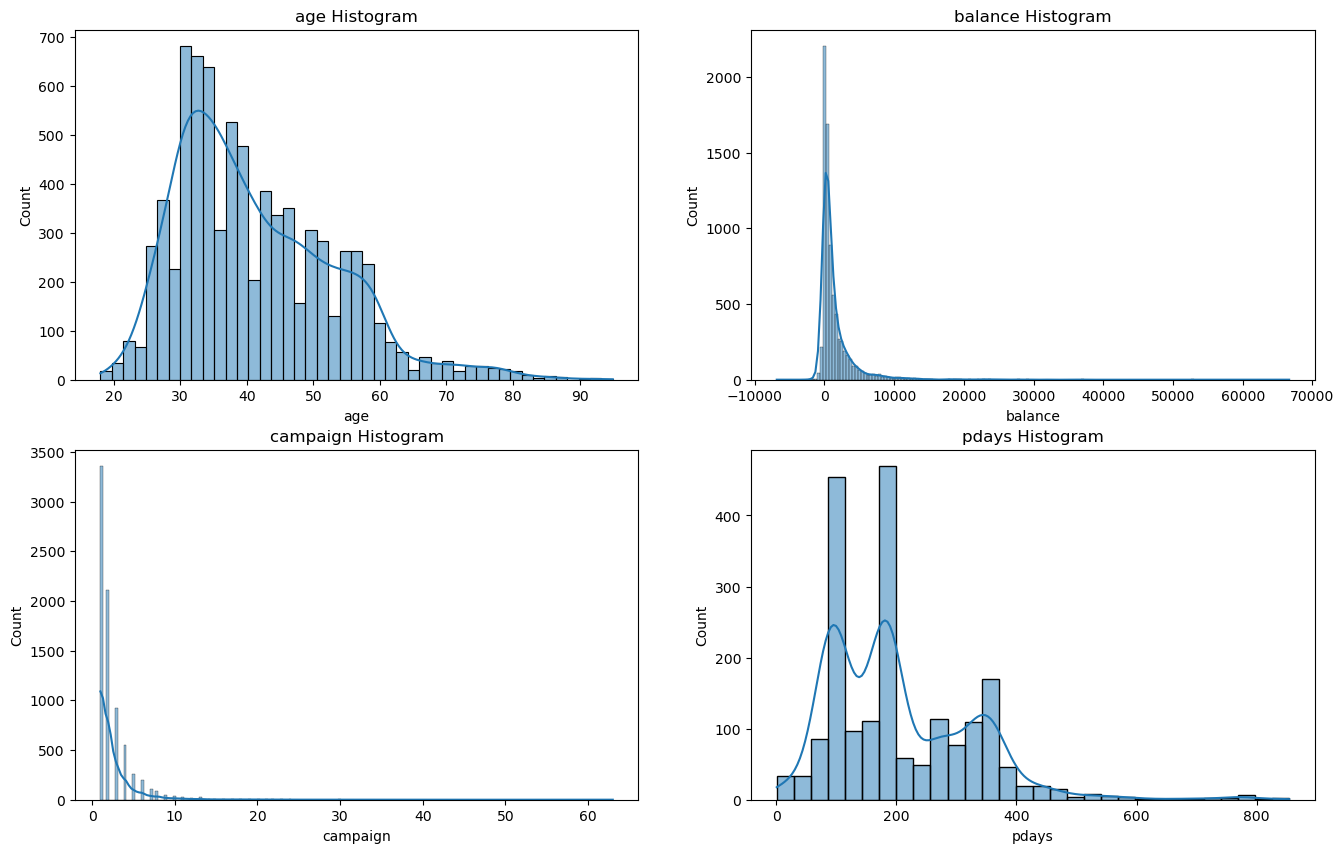

In [76]:
num_cols = df.select_dtypes(include="number").drop(columns="pdays").columns

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes = axes.flatten()

for dex, i in enumerate(num_cols):
    sns.histplot(data=df[i], ax=axes[dex], kde=True)
    axes[dex].set_title(f"{i} Histogram")

contacted = df[df["pdays"] != -1]["pdays"]

sns.histplot(data=contacted, ax=axes[(dex + 1)], kde=True) 
axes[(dex + 1)].set_title(f"pdays Histogram")

for j in range((len(num_cols)+1), len(axes)):
    fig.delaxes(axes[j])

plt.show()

>  **Insight distribusi numerik:**
> - `age` cenderung mendekati distribusi normal dengan sedikit *right-skew*, terpusat di rentang 30–50 tahun.
> - `balance` sangat *right-skewed*, mayoritas pelanggan memiliki saldo rendah/menengah, namun ada ekor panjang pelanggan dengan saldo sangat tinggi (bahkan beberapa bernilai negatif).
> - `campaign` juga *right-skewed* tajam, sebagian besar pelanggan hanya dihubungi 1–3 kali, tapi ada sejumlah kecil yang dihubungi puluhan kali.
> - `pdays` didominasi nilai -1 (belum pernah dihubungi), sehingga distribusinya menumpuk tajam di satu titik lalu menyebar untuk sisanya.

Cardinality of Categorical Value

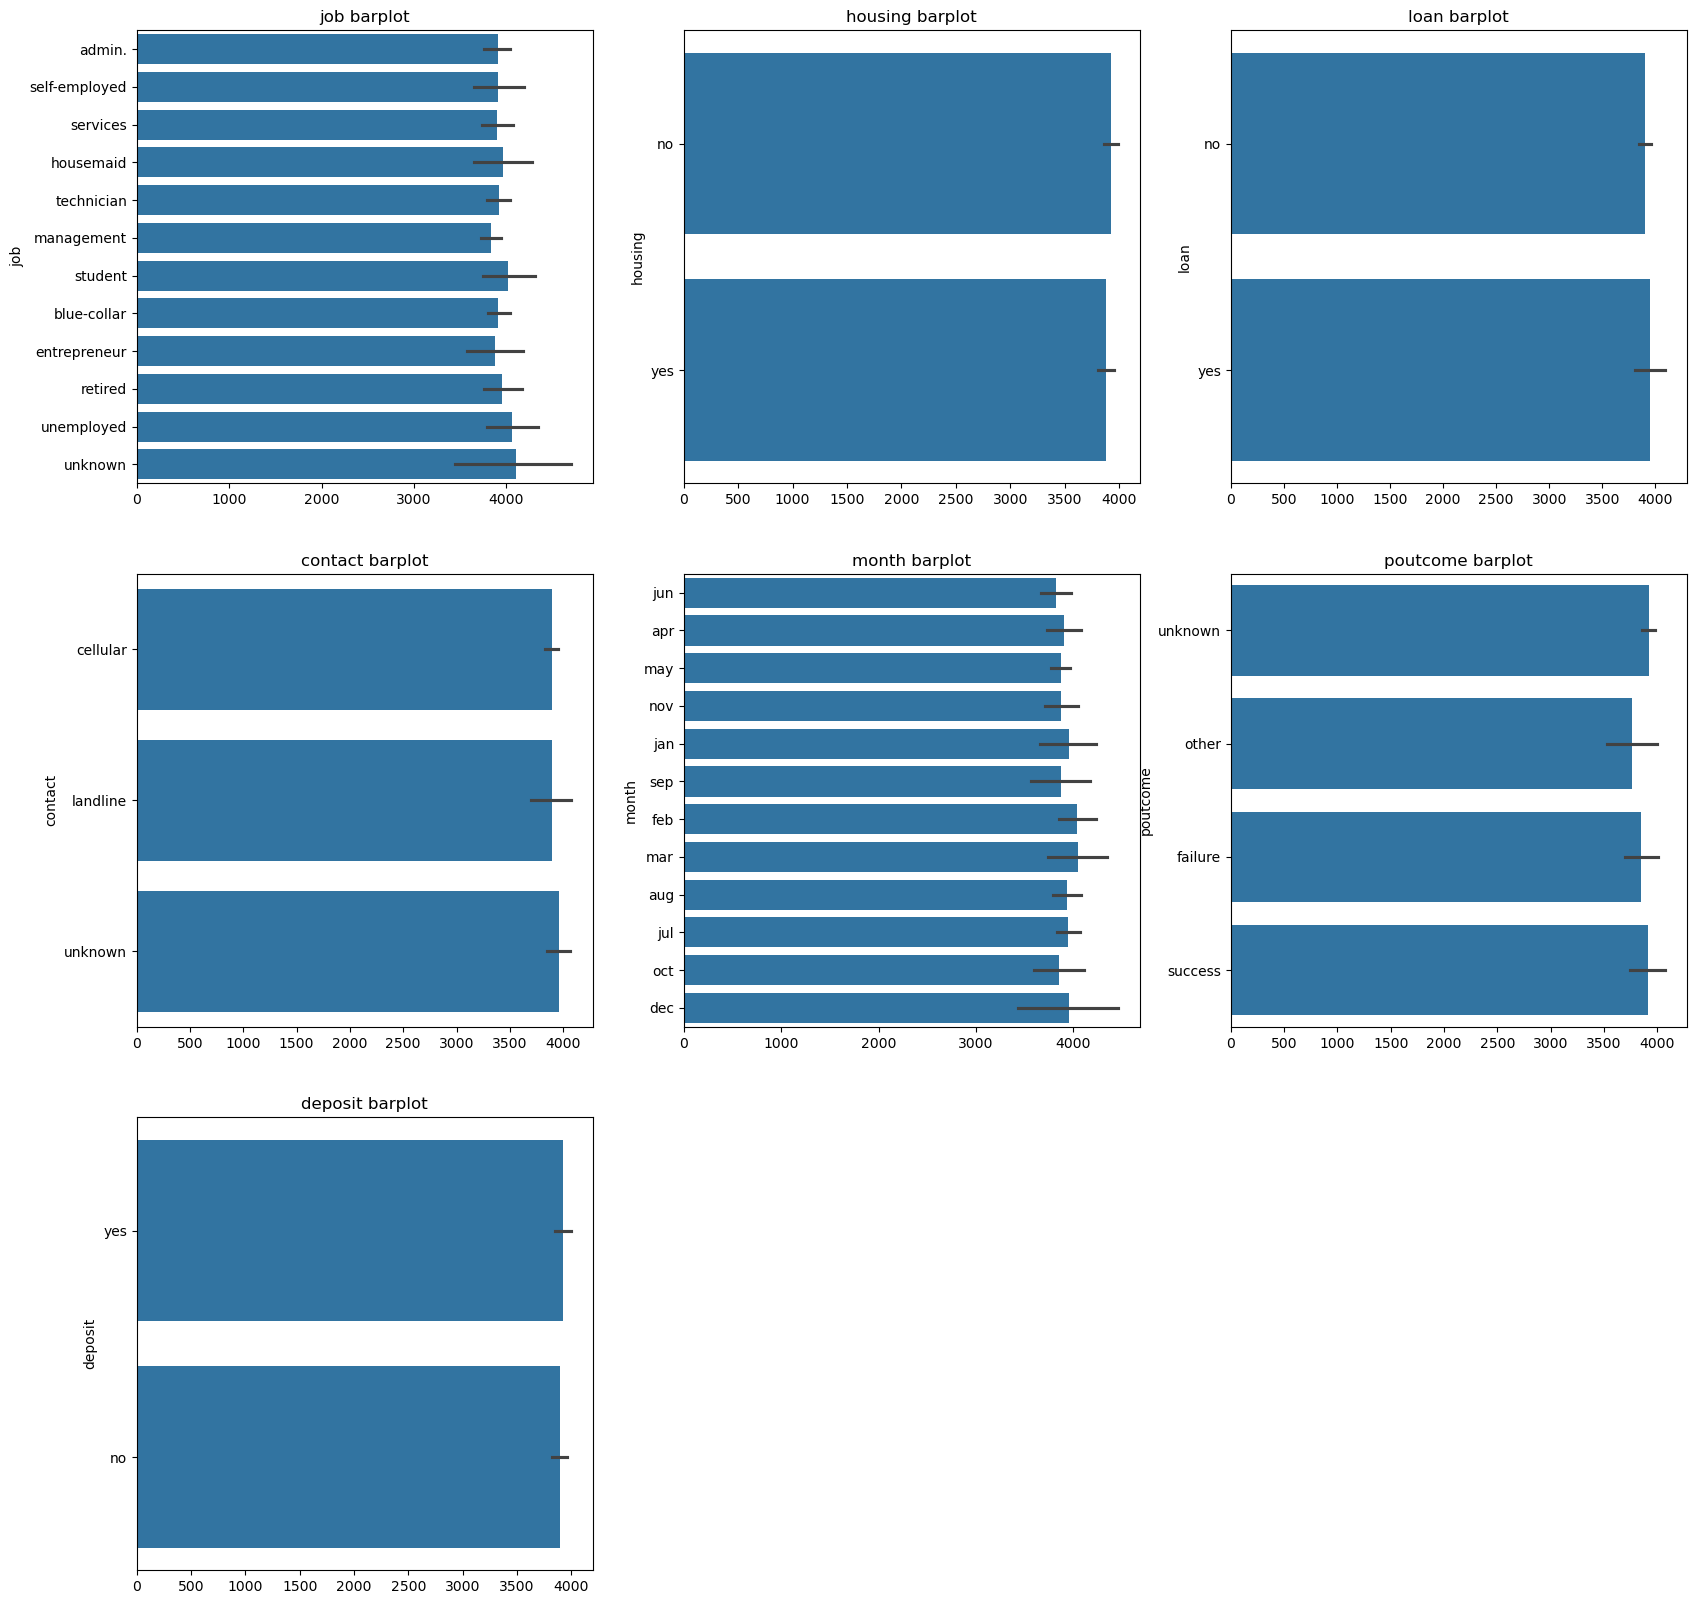

In [77]:
cat_cols = df.select_dtypes(include="object").columns

fig, axes = plt.subplots(3, 3, figsize=(20, 20))

axes = axes.flatten()

for dex, i in enumerate(cat_cols):
    sns.barplot(data=df[i], ax=axes[dex])
    axes[dex].set_title(f"{i} barplot")

for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])

plt.show()

> **Insight cardinality:** `job` dan `month` memiliki 12 kategori, `poutcome` 4 kategori, `contact` 3 kategori, sedangkan `housing`, `loan`, dan `deposit` bersifat biner (2 kategori). Tidak ada kolom dengan **cardinality tinggi** (misalnya ID atau nama unik per baris), sehingga seluruh kolom kategorikal aman untuk di-*encode* langsung dengan One-Hot Encoding tanpa risiko ledakan dimensi (*curse of dimensionality*) yang berarti.

Outlier Values

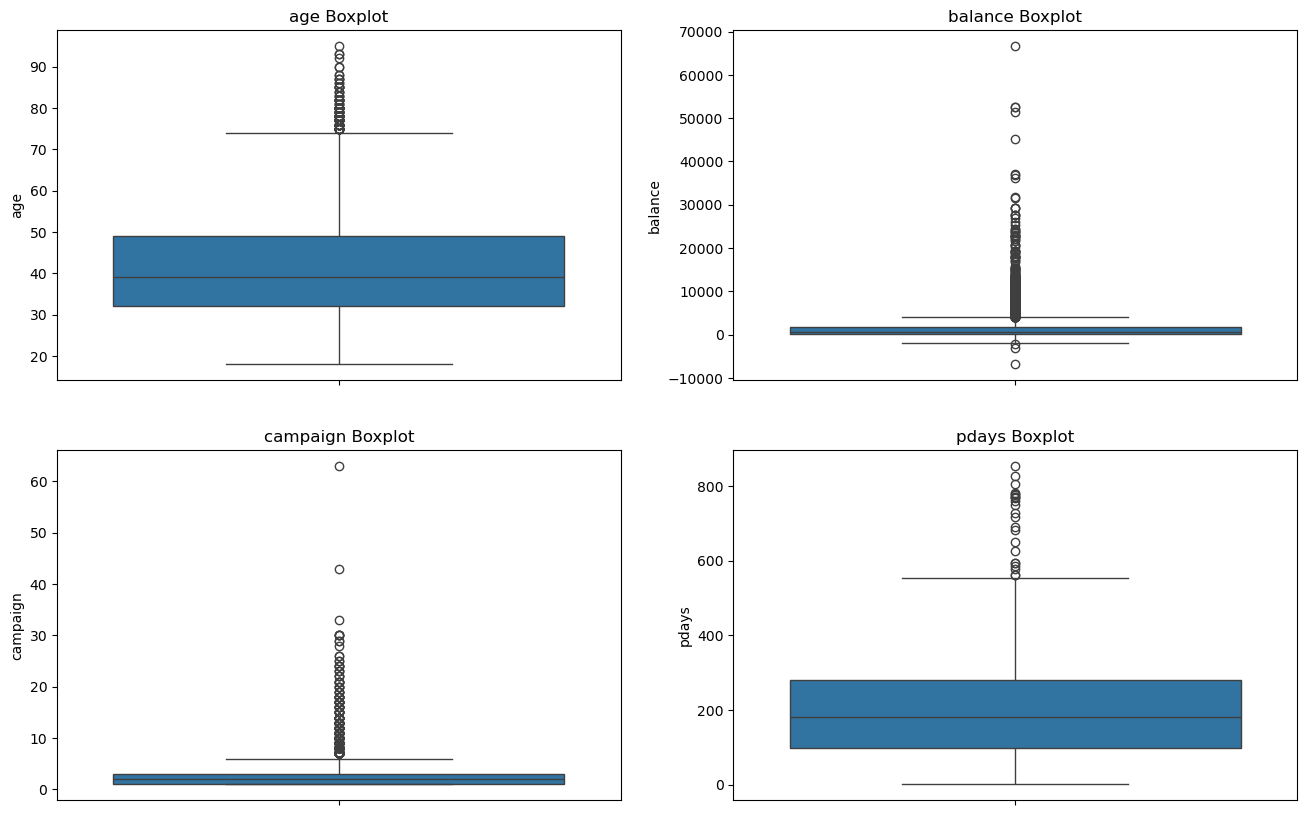

In [78]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes = axes.flatten()

for dex, i in enumerate(num_cols):
    sns.boxplot(data=df[i], ax=axes[dex])
    axes[dex].set_title(f"{i} Boxplot")

sns.boxplot(data=contacted, ax=axes[(dex + 1)]) 
axes[(dex + 1)].set_title(f"pdays Boxplot")

for j in range((len(num_cols)+1), len(axes)):
    fig.delaxes(axes[j])

plt.show()

In [79]:
for i in df.select_dtypes(include='number').drop(columns="pdays", errors="coerce"):
    q1 =  df[i].quantile(0.25)
    q3 = df[i].quantile(0.75)
    iqr = q3 - q1

    upper_bound = q3 + iqr * 1.5
    lower_bound = q1 - iqr * 1.5

    print(f"==== {i} Outlier ====")
    print(f"{i} column upper bound: {upper_bound}")
    print(f"{i} column lower bound: {lower_bound}")
    print(f"Total upper outlier in column {i}: {df[(df[i]>upper_bound)].shape[0]}")
    print(f"Total lower outlier in column {i}: {df[(df[i]<lower_bound)].shape[0]}\n")

q1 =  contacted.quantile(0.25)
q3 = contacted.quantile(0.75)
iqr = q3 - q1

upper_bound = q3 + iqr * 1.5
lower_bound = q1 - iqr * 1.5

print(f"==== pdays Outlier ====")
print(f"pdays column upper bound: {upper_bound}")
print(f"pdays column lower bound: {lower_bound}")
print(f"Total upper outlier in column pdays: {(contacted > upper_bound).sum()}")
print(f"Total lower outlier in column pdays: {(contacted < lower_bound).sum()}")

==== age Outlier ====
age column upper bound: 74.5
age column lower bound: 6.5
Total upper outlier in column age: 121
Total lower outlier in column age: 0

==== balance Outlier ====
balance column upper bound: 4019.5
balance column lower bound: -2208.5
Total upper outlier in column balance: 733
Total lower outlier in column balance: 3

==== campaign Outlier ====
campaign column upper bound: 6.0
campaign column lower bound: -2.0
Total upper outlier in column campaign: 429
Total lower outlier in column campaign: 0

==== pdays Outlier ====
pdays column upper bound: 555.5
pdays column lower bound: -176.5
Total upper outlier in column pdays: 23
Total lower outlier in column pdays: 0


Extreme outlier

In [80]:
for i in df.select_dtypes(include='number').drop(columns="pdays", errors="coerce"):
    q1 =  df[i].quantile(0.25)
    q3 = df[i].quantile(0.75)
    iqr = q3 - q1

    upper_bound = q3 + iqr * 3
    lower_bound = q1 - iqr * 3

    print(f"==== {i} Extreme Outlier ====")
    print(f"{i} column upper bound: {upper_bound}")
    print(f"{i} column lower bound: {lower_bound}")
    print(f"Total upper outlier in column {i}: {df[(df[i]>upper_bound)].shape[0]}")
    print(f"Total lower outlier in column {i}: {df[(df[i]<lower_bound)].shape[0]}\n")

q1 =  contacted.quantile(0.25)
q3 = contacted.quantile(0.75)
iqr = q3 - q1

upper_bound = q3 + iqr * 3
lower_bound = q1 - iqr * 3

print(f"==== pdays Extreme Outlier ====")
print(f"pdays column upper bound: {upper_bound}")
print(f"pdays column lower bound: {lower_bound}")
print(f"Total upper outlier in column pdays: {(contacted > upper_bound).sum()}")
print(f"Total lower outlier in column pdays: {(contacted < lower_bound).sum()}")

==== age Extreme Outlier ====
age column upper bound: 100.0
age column lower bound: -19.0
Total upper outlier in column age: 0
Total lower outlier in column age: 0

==== balance Extreme Outlier ====
balance column upper bound: 6355.0
balance column lower bound: -4544.0
Total upper outlier in column balance: 375
Total lower outlier in column balance: 1

==== campaign Extreme Outlier ====
campaign column upper bound: 9.0
campaign column lower bound: -5.0
Total upper outlier in column campaign: 190
Total lower outlier in column campaign: 0

==== pdays Extreme Outlier ====
pdays column upper bound: 830.0
pdays column lower bound: -451.0
Total upper outlier in column pdays: 1
Total lower outlier in column pdays: 0


Skewness

In [81]:
for i in df.select_dtypes(include='number').drop(columns="pdays", errors="coerce"):
    print(f"==== {i} Skewness ====")
    skew_val = df[i].skew()
    print(f"Skewness score: {skew_val}\n")

print(f"==== pdays skewness ====")
skew_val = contacted.skew()
print(f"Skewness score: {skew_val}")

==== age Skewness ====
Skewness score: 0.867620162363191

==== balance Skewness ====
Skewness score: 6.760662339910582

==== campaign Skewness ====
Skewness score: 5.538155830068887

==== pdays skewness ====
Skewness score: 1.263554148865178


Max Value to 99 Percentile Comparison

In [82]:
for i in df.select_dtypes(include="number").drop(columns="pdays", errors="coerce"):
    p99 = df[i].quantile(0.99)
    max_val = df[i].max()
    
    print(f"==== {i} Max to 99 Comparison ====")
    print(f"99% of data is below: {p99}")
    print(f"The maximum value is: {max_val}\n")

p99 = contacted.quantile(0.99)
max_val = contacted.max()

print(f"==== pdays Max to 99 Comparison ====")
print(f"99% of data is below: {p99}")
print(f"The maximum value is: {max_val}\n")

==== age Max to 99 Comparison ====
99% of data is below: 77.0
The maximum value is: 95

==== balance Max to 99 Comparison ====
99% of data is below: 13319.68000000002
The maximum value is: 66653

==== campaign Max to 99 Comparison ====
99% of data is below: 13.0
The maximum value is: 63

==== pdays Max to 99 Comparison ====
99% of data is below: 579.3999999999996
The maximum value is: 854



In [83]:
df.shape

(7813, 11)

> if we look at the result here we can see from 7813 data all of the numerical columns have their own share of outlier. But only 3 columns (`Balance`, `campaign` and `pdays`) the one who have extreme outlier. and when the skewness was checked we can see there are 2 columns which are heavily skewed reaching the value of ~5 to ~6.

## **Section 4. Exploratory Data Analysis (EDA)**

> 🎯 *Tujuan:* Menggali pola dan hubungan dalam data training untuk membangun intuisi sebelum masuk ke tahap modeling.

**4.1 Univariate Analysis**
- Distribusi target
- Distribusi fitur numerik
- Distribusi fitur kategorikal

> 🎯 *Tujuan:* Memahami karakteristik tiap variabel secara individual, termasuk seberapa seimbang distribusi target.

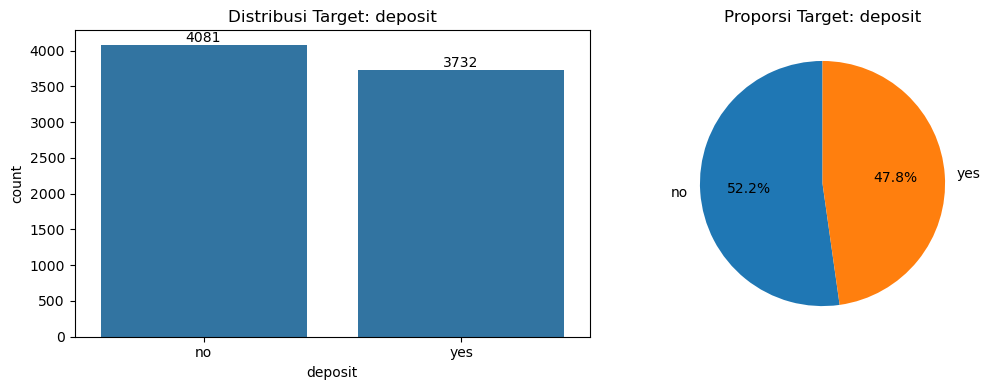

deposit
no     4081
yes    3732
Name: count, dtype: int64
deposit
no     52.23
yes    47.77
Name: proportion, dtype: float64


In [84]:
#Distribusi target 
target_counts = df['deposit'].value_counts()
target_pct = df['deposit'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(data=df, x='deposit', order=['no', 'yes'], ax=ax[0])
ax[0].set_title("Distribusi Target: deposit")
for p in ax[0].patches:
    ax[0].annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width()/2, p.get_height()),
                   ha='center', va='bottom')

ax[1].pie(target_pct, labels=target_pct.index, autopct='%1.1f%%', startangle=90,
          colors=sns.color_palette()[:2])
ax[1].set_title("Proporsi Target: deposit")
plt.tight_layout()
plt.show()

print(target_counts)
print(target_pct.round(2))

> **Insight:** Distribusi target relatif **seimbang** (+/- 52% `no` vs +/- 48% `yes`), sehingga teknik penanganan *imbalanced data* yang agresif (seperti SMOTE) **tidak wajib** dilakukan, cukup dengan strategi ringan seperti `class_weight='balanced'` jika diperlukan.

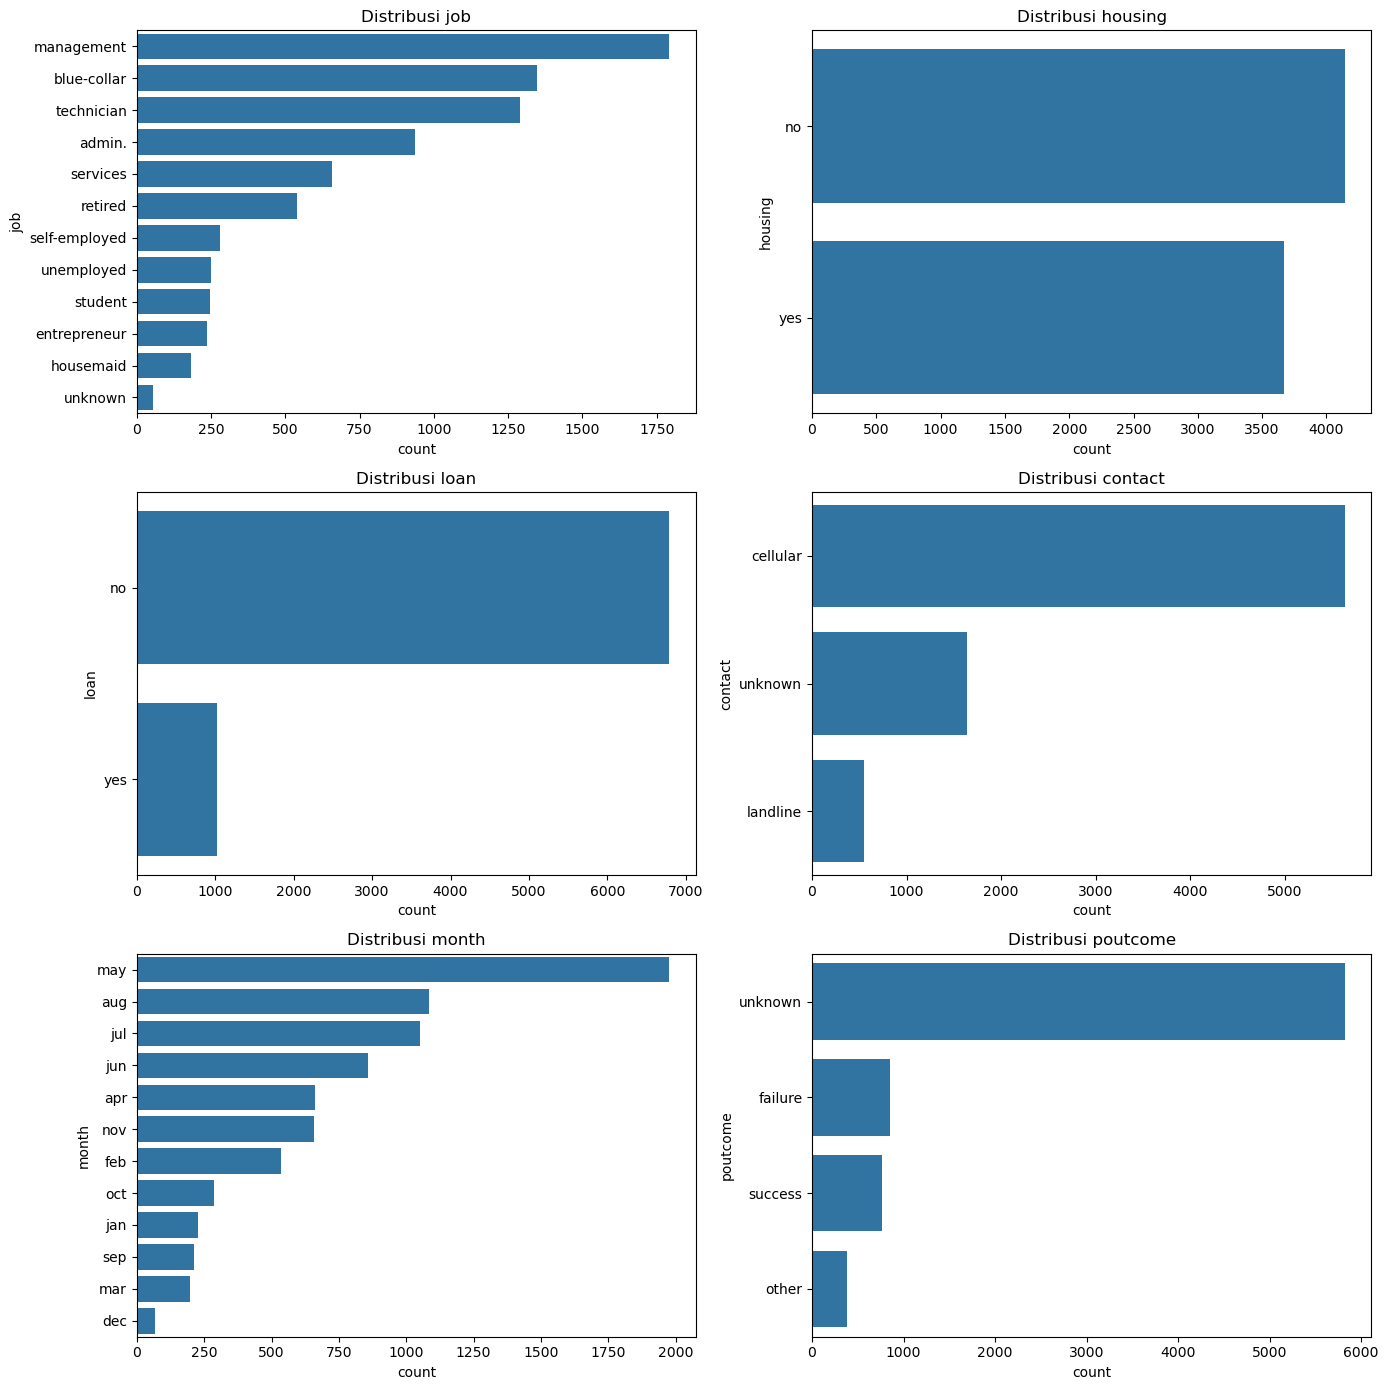

In [85]:
#Distribusi fitur kategorikal (proporsi tiap kategori) 
cat_features = ['job', 'housing', 'loan', 'contact', 'month', 'poutcome']

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()
for ax, col in zip(axes, cat_features):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=ax)
    ax.set_title(f"Distribusi {col}")
plt.tight_layout()
plt.show()

>  **Insight fitur kategorikal:**
> - `job`: didominasi `management`, `blue-collar`, dan `technician`, mencerminkan komposisi pekerjaan nasabah bank pada umumnya.
> - `housing`: proporsi pelanggan dengan pinjaman rumah cukup berimbang antara ya/tidak.
> - `loan`: mayoritas pelanggan **tidak** memiliki pinjaman pribadi aktif.
> - `contact`: sebagian besar dihubungi lewat `cellular`, mengindikasikan preferensi channel komunikasi saat ini.
> - `month`: campaign terkonsentrasi pada bulan-bulan tertentu (mid-year), menunjukkan pola musiman.
> - `poutcome`: mayoritas `unknown` (belum ada campaign sebelumnya), diikuti `failure`.

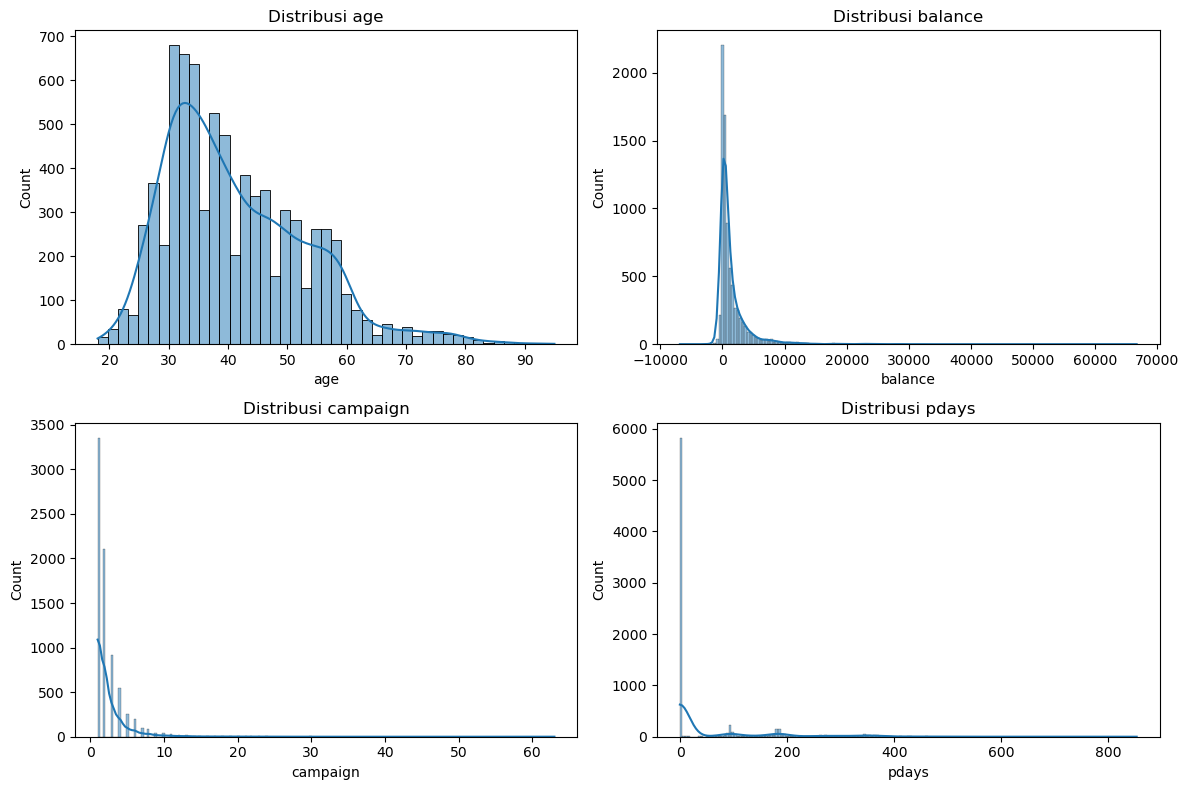

,skewness
age,0.867620
balance,6.760662
campaign,5.538156
pdays,2.411313


In [86]:
#Distribusi fitur numerik (ringkasan ulang dengan sudut pandang univariate)
num_features = ['age', 'balance', 'campaign', 'pdays']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for ax, col in zip(axes, num_features):
    sns.histplot(data=df, x=col, kde=True, ax=ax)
    ax.set_title(f"Distribusi {col}")
plt.tight_layout()
plt.show()

df[num_features].skew().rename("skewness").to_frame()

>  **Insight:** Sejalan dengan temuan Section 3.4, `balance`, `campaign`, dan `pdays` memiliki *skewness* positif yang tinggi (ekor panjang ke kanan), sedangkan `age` relatif lebih simetris. 

**4.2 Bivariate Analysis (terhadap Target)**

> 🎯 *Tujuan:* Mencari pola hubungan antara tiap fitur dengan target, untuk menjawab langsung Problem Statement di Section 1.2.

> 📌 Ini bagian paling penting untuk menjawab Problem Statement di Section 1.2 — cari pola antara tiap fitur dengan target, bukan sekadar plot tanpa insight.

C:\Users\nadya\AppData\Local\Temp\ipykernel_28704\3397731998.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conv_rate.values, y=conv_rate.index, ax=ax, palette="viridis")
C:\Users\nadya\AppData\Local\Temp\ipykernel_28704\3397731998.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conv_rate.values, y=conv_rate.index, ax=ax, palette="viridis")
C:\Users\nadya\AppData\Local\Temp\ipykernel_28704\3397731998.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conv_rate.values, y=conv_rate.index, ax=ax, palette="viridis")
C:\Users\nady

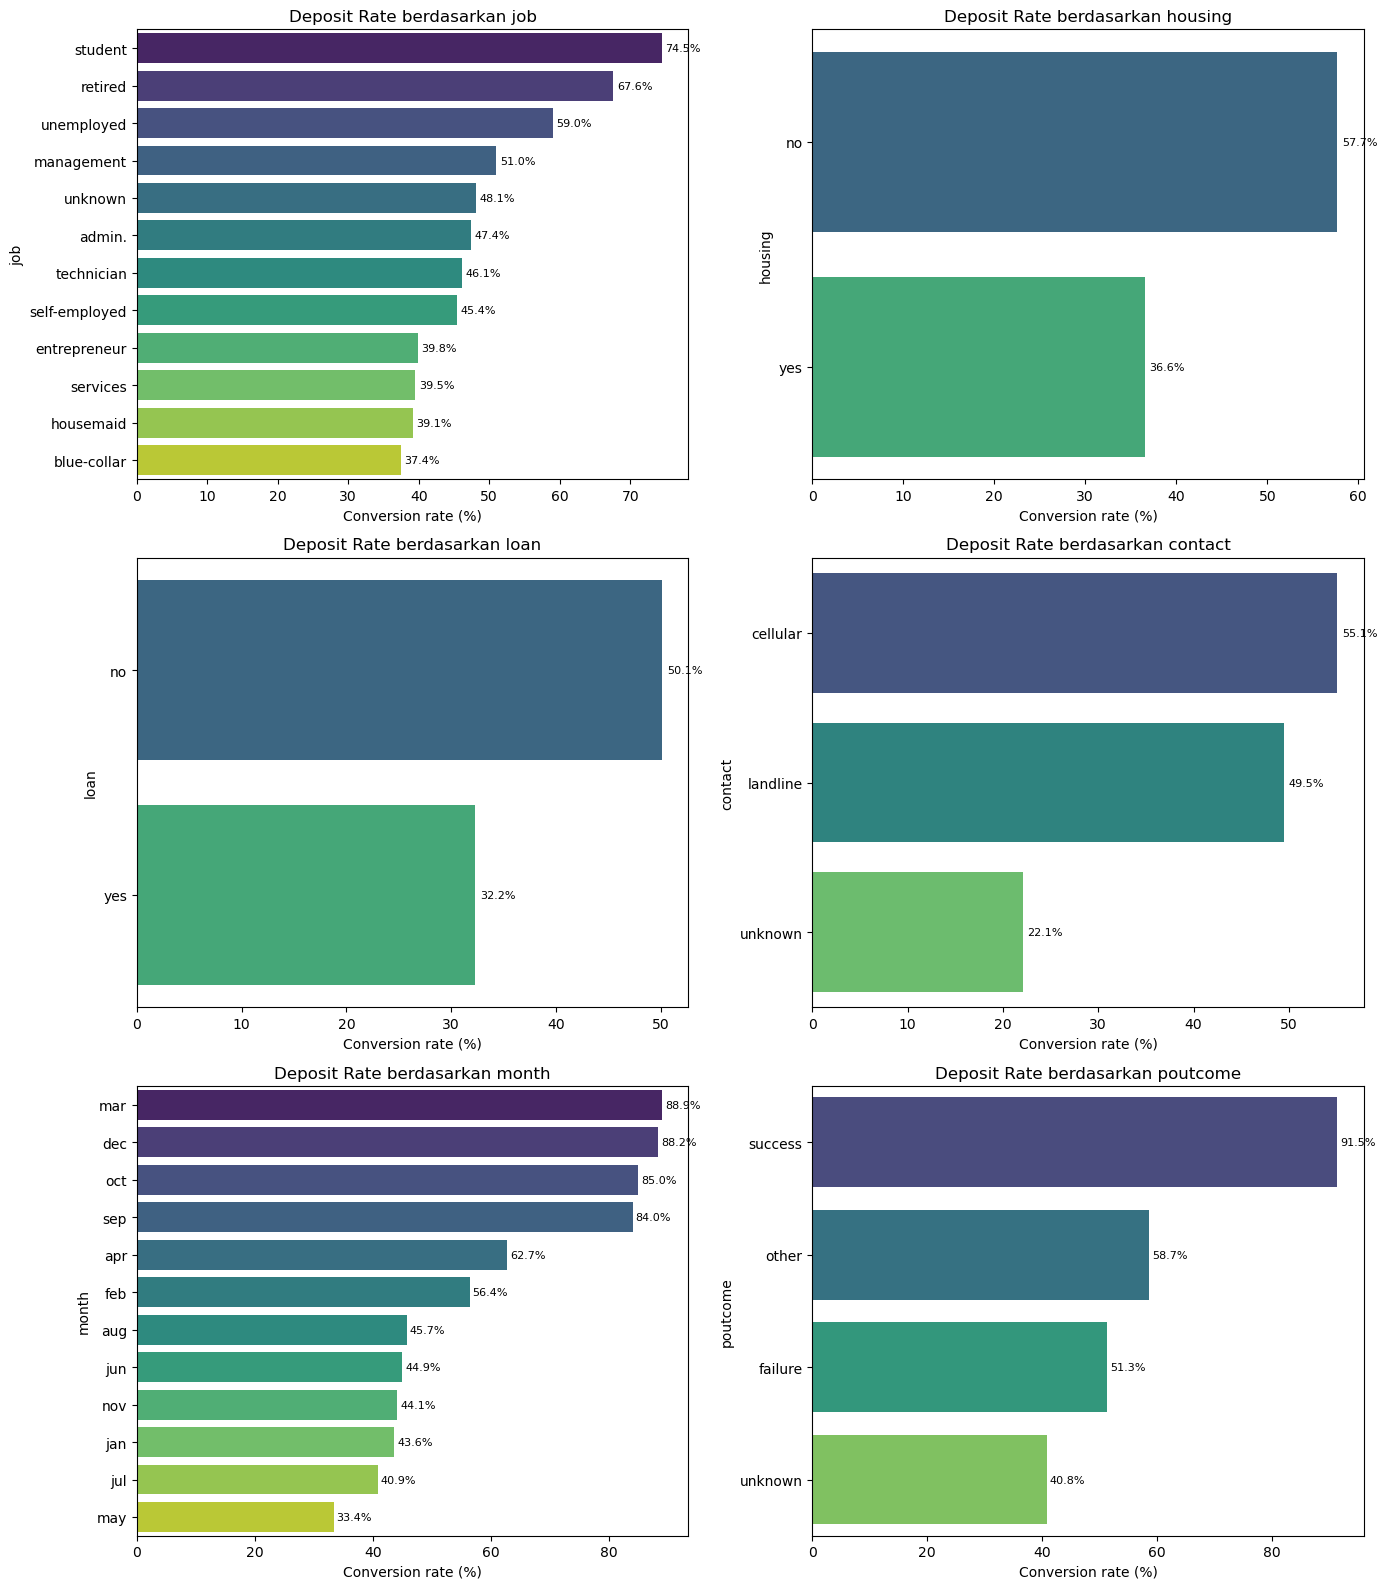

In [87]:
#Bivariate: fitur kategorikal vs conversion rate (deposit = yes)
fig, axes = plt.subplots(3, 2, figsize=(14, 16))
axes = axes.flatten()

for ax, col in zip(axes, cat_features):
    conv_rate = (df.groupby(col)['deposit']
                   .apply(lambda x: (x == 'yes').mean() * 100)
                   .sort_values(ascending=False))
    sns.barplot(x=conv_rate.values, y=conv_rate.index, ax=ax, palette="viridis")
    ax.set_xlabel("Conversion rate (%)")
    ax.set_title(f"Deposit Rate berdasarkan {col}")
    for i, v in enumerate(conv_rate.values):
        ax.text(v + 0.5, i, f"{v:.1f}%", va='center', fontsize=8)

plt.tight_layout()
plt.show()

> **Insight bivariate kategorikal**
> - `poutcome = success` memiliki conversion rate **jauh lebih tinggi** dibanding kategori lain, pelanggan yang sebelumnya pernah berhasil di-convert sangat mungkin membuka deposito lagi. Ini sinyal paling kuat untuk prioritas campaign berikutnya.
> - `contact = cellular` menunjukkan conversion rate lebih tinggi dibanding `telephone`/`unknown`, mendukung strategi fokus pada kontak seluler.
> - Bulan-bulan tertentu (`month`) menunjukkan conversion rate lebih tinggi dibanding bulan lain, mengindikasikan pola musiman yang dapat dimanfaatkan untuk penjadwalan campaign.
> - Pelanggan **tanpa** `housing` loan dan **tanpa** `loan` pribadi cenderung memiliki conversion rate lebih tinggi, masuk akal karena beban finansial lebih rendah sehingga lebih leluasa mengalokasikan dana ke deposito.
> - Variasi conversion rate antar kategori `job` menunjukkan segmen pekerjaan tertentu (misalnya `student`, `retired`) cenderung lebih responsif dibanding segmen lain seperti `blue-collar`.

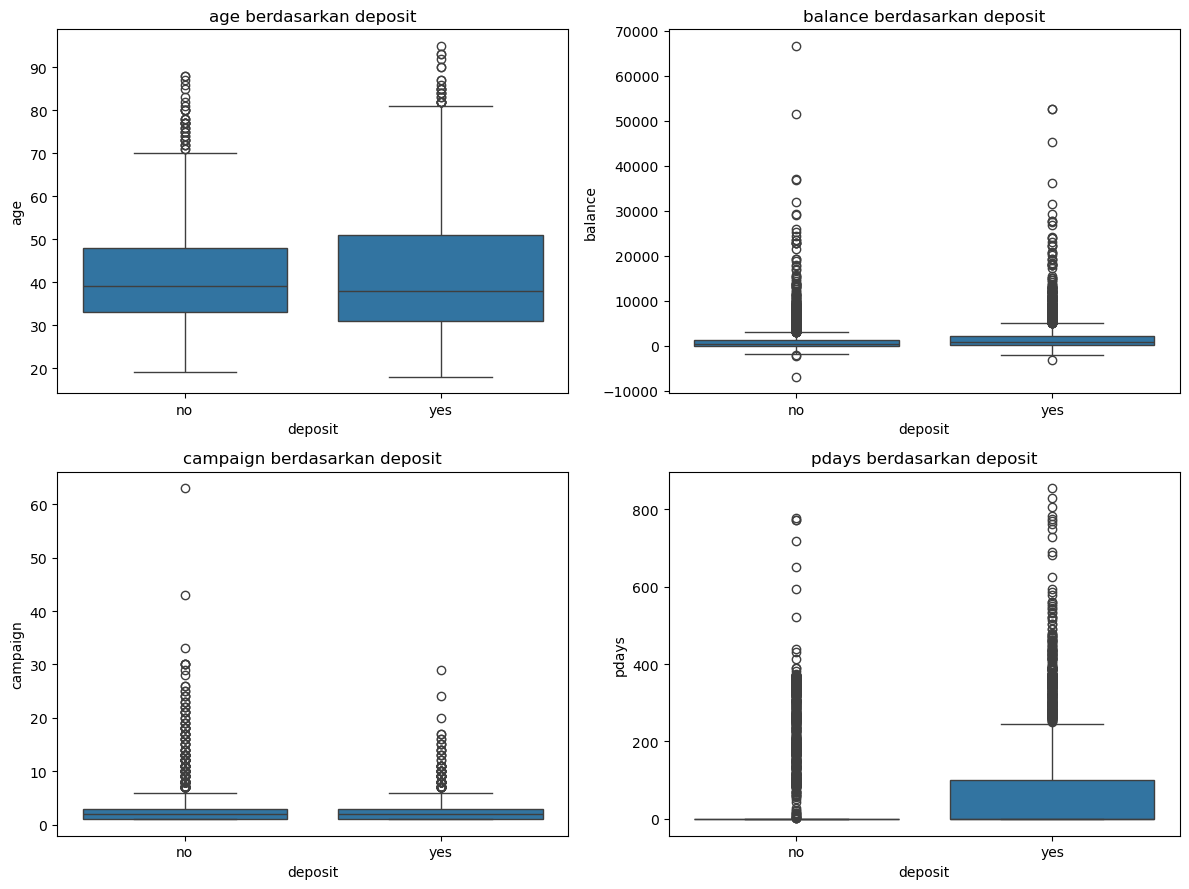

In [88]:
#Bivariate: fitur numerik vs target 
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()
for ax, col in zip(axes, num_features):
    sns.boxplot(data=df, x='deposit', y=col, order=['no', 'yes'], ax=ax)
    ax.set_title(f"{col} berdasarkan deposit")
plt.tight_layout()
plt.show()

> 📌 **Insight bivariate numerik**
> - `balance`: pelanggan yang membuka deposito (`yes`) cenderung memiliki **median saldo lebih tinggi** dibanding yang menolak, mendukung hipotesis bahwa kapasitas finansial berpengaruh terhadap keputusan investasi.
> - `campaign`: pelanggan yang **menolak** cenderung memiliki jumlah kontak lebih tinggi pada beberapa kasus, mengindikasikan bahwa terlalu sering menghubungi pelanggan yang sudah menunjukkan penolakan justru tidak efektif (*diminishing returns*, bahkan berpotensi mengganggu).
> - `pdays` & riwayat kontak sebelumnya berkaitan erat dengan `poutcome`, pelanggan dengan jeda yang wajar sejak kontak terakhir dan riwayat sukses cenderung lebih responsif.
> - `age` tidak menunjukkan perbedaan median yang tajam antar kelas target, namun sebaran pada kelompok usia tertentu (misalnya lanjut usia/`retired` dan usia muda/`student`) tetap relevan dilihat bersama fitur `job`.

**4.3 Correlation & Multicollinearity Check**

> 🎯 *Tujuan:* Mengecek hubungan antar fitur untuk mendeteksi multikolinearitas yang bisa mengganggu interpretasi model nanti.

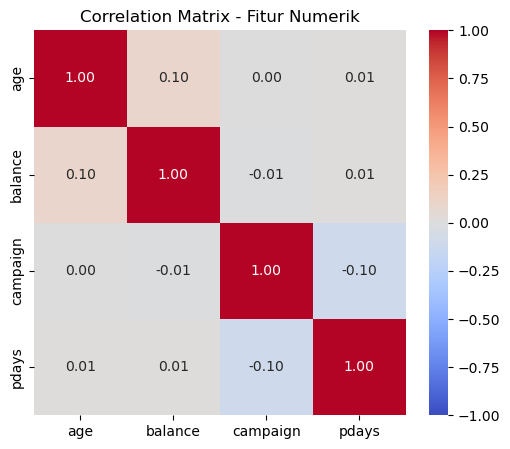

In [89]:
#Korelasi antar fitur numerik
plt.figure(figsize=(6, 5))
corr = df[num_features].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix - Fitur Numerik")
plt.show()

C:\Users\nadya\AppData\Local\Temp\ipykernel_28704\2267246054.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=assoc_series.values, y=assoc_series.index, palette="mako")


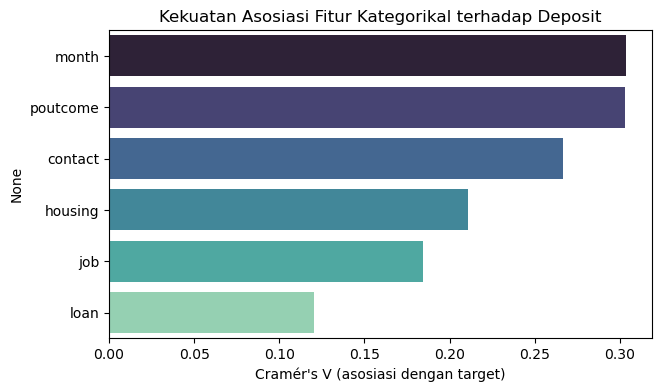

month       0.303370
poutcome    0.303076
contact     0.266412
housing     0.210988
job         0.184186
loan        0.120447
dtype: float64

In [90]:
# Asosiasi kategorikal terhadap target menggunakan Cramér's V 
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    r, k = ct.shape
    return np.sqrt((chi2 / n) / (min(r, k) - 1))

assoc = {col: cramers_v(df[col], df['deposit']) for col in cat_features}
assoc_series = pd.Series(assoc).sort_values(ascending=False)

plt.figure(figsize=(7, 4))
sns.barplot(x=assoc_series.values, y=assoc_series.index, palette="mako")
plt.xlabel("Cramér's V (asosiasi dengan target)")
plt.title("Kekuatan Asosiasi Fitur Kategorikal terhadap Deposit")
plt.show()

assoc_series

> **Insight korelasi & multicollinearity:**
> - Korelasi antar fitur numerik (`age`, `balance`, `campaign`, `pdays`) **tergolong lemah** (semuanya di bawah 0.3), sehingga **tidak ditemukan indikasi multikolinearitas** yang berarti aman digunakan bersamaan dalam model, khususnya untuk model linear seperti Logistic Regression.
> - Berdasarkan Cramér's V, `poutcome` dan `contact` menunjukkan **asosiasi terkuat** terhadap target `deposit`, sejalan dengan temuan bivariate di atas. Ini mengonfirmasi bahwa riwayat campaign sebelumnya dan channel komunikasi adalah dua faktor kunci yang perlu diprioritaskan tim marketing.

**4.4 Multivariate / Interaction Analysis (opsional)**

> 🎯 *Tujuan:* Menelusuri interaksi antara beberapa fitur sekaligus untuk pola yang lebih kompleks dari yang bisa ditangkap analisis dua arah.



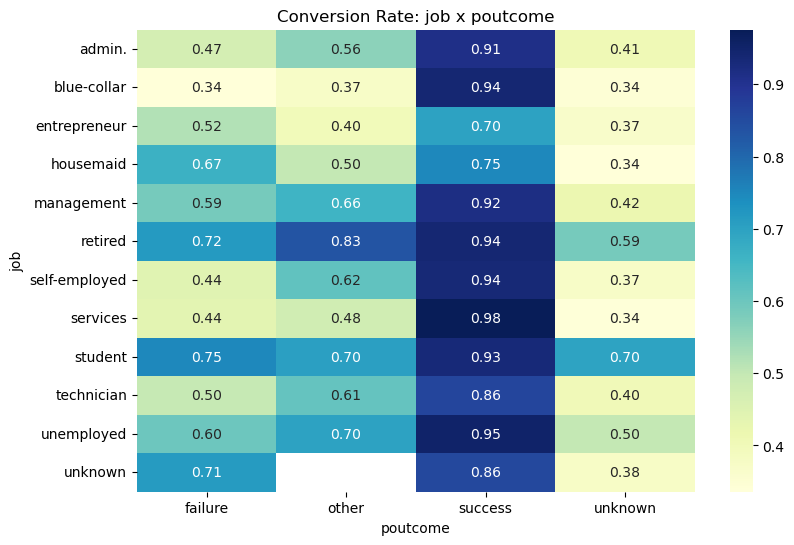

In [91]:
#conversion rate berdasarkan job x poutcome
pivot = (df.assign(deposit_flag=(df['deposit'] == 'yes').astype(int))
           .pivot_table(index='job', columns='poutcome', values='deposit_flag', aggfunc='mean'))

plt.figure(figsize=(9, 6))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Conversion Rate: job x poutcome")
plt.show()

C:\Users\nadya\AppData\Local\Temp\ipykernel_28704\1455041599.py:7: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot2 = df_temp.pivot_table(index='age_group', columns='housing', values='deposit_flag', aggfunc='mean')


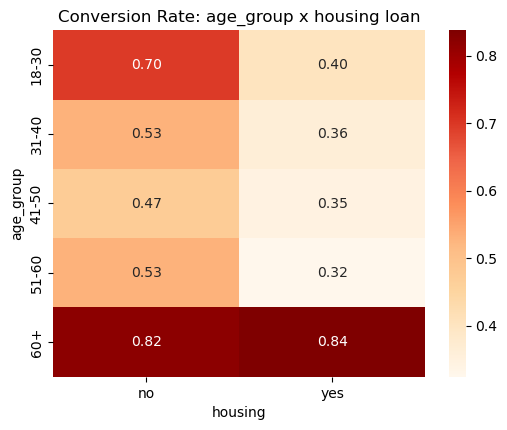

In [92]:
# usia dikelompokkan x status pinjaman terhadap conversion rate
df_temp = df.copy()
df_temp['age_group'] = pd.cut(df_temp['age'], bins=[17, 30, 40, 50, 60, 96],
                               labels=['18-30', '31-40', '41-50', '51-60', '60+'])
df_temp['deposit_flag'] = (df_temp['deposit'] == 'yes').astype(int)

pivot2 = df_temp.pivot_table(index='age_group', columns='housing', values='deposit_flag', aggfunc='mean')

plt.figure(figsize=(6, 4.5))
sns.heatmap(pivot2, annot=True, fmt=".2f", cmap="OrRd")
plt.title("Conversion Rate: age_group x housing loan")
plt.show()

> **Insight multivariate**
> - Kombinasi `job x poutcome` menunjukkan bahwa hampir **semua segmen pekerjaan** memiliki conversion rate jauh lebih tinggi ketika `poutcome = success`, menegaskan riwayat campaign sebelumnya sebagai sinyal terkuat lintas segmen.
> - Kombinasi `age_group x housing` menunjukkan bahwa pelanggan **usia lebih tua tanpa pinjaman rumah aktif** cenderung memiliki conversion rate tertinggi — kombinasi ini bisa menjadi salah satu **segmen prioritas** untuk campaign berikutnya, sejalan dengan Goals di Section 1.3.


## **Section 5. Data Preparation**

> 🎯 *Tujuan:* Mengubah data mentah menjadi bentuk siap pakai untuk pemodelan (numerik, terskala, tanpa kategori yang belum di-encode).

**5.1 Initialization**
- Initialization function
- Define Feature and Target

> 🎯 *Tujuan:* Menyiapkan fungsi bantu dan mendefinisikan mana kolom fitur (X) dan target (y) sebelum transformasi dimulai.

In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7813 entries, 0 to 7812
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   age       7813 non-null   int64 
 1   job       7813 non-null   object
 2   balance   7813 non-null   int64 
 3   housing   7813 non-null   object
 4   loan      7813 non-null   object
 5   contact   7813 non-null   object
 6   month     7813 non-null   object
 7   campaign  7813 non-null   int64 
 8   pdays     7813 non-null   int64 
 9   poutcome  7813 non-null   object
 10  deposit   7813 non-null   object
dtypes: int64(4), object(7)
memory usage: 671.6+ KB


In [94]:
feature = df.drop(columns="deposit")
target = df["deposit"].map({"yes": 1, "no": 0})

**5.2 Constructing `Training` and `Testing` Data (from `Seen` Dataset)**

> 🎯 *Tujuan:* Membagi data `Seen` menjadi training dan testing untuk keperluan pengembangan dan evaluasi model.

In [95]:
x_train, x_test, y_train, y_test = train_test_split(feature, target, test_size=0.2, random_state=RANDOM_STATE)

x_train.reset_index(inplace=True, drop=True)
y_train.reset_index(inplace=True, drop=True)
x_test.reset_index(inplace=True, drop=True)
y_test.reset_index(inplace=True, drop=True)

**5.3 Handling Imbalanced Data (jika relevan)**

> 🎯 *Tujuan:* Menangani ketimpangan proporsi kelas target supaya model tidak bias ke kelas mayoritas.

> 📌 Cek proporsi kelas target di Section 5.1. Kalau timpang (misal 90:10), pertimbangkan strategi seperti class_weight, SMOTE, atau undersampling — **tapi ingat, teknik resampling hanya boleh diterapkan pada data training**, tidak pernah pada data testing/unseen, supaya evaluasi tetap realistis.

In [96]:
print("--- Absolute Counts ---")
print(target.value_counts())

print("\n--- Relative Percentages ---")
print(target.value_counts(normalize=True) * 100)

--- Absolute Counts ---
deposit
0    4081
1    3732
Name: count, dtype: int64

--- Relative Percentages ---
deposit
0    52.233457
1    47.766543
Name: proportion, dtype: float64


**5.4 Data Transformation (Feature Engineering)**

> 🎯 *Tujuan:* Melakukan encoding, scaling, atau transformasi lain agar data sesuai kebutuhan algoritma yang dipakai.

In [97]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6250 entries, 0 to 6249
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   age       6250 non-null   int64 
 1   job       6250 non-null   object
 2   balance   6250 non-null   int64 
 3   housing   6250 non-null   object
 4   loan      6250 non-null   object
 5   contact   6250 non-null   object
 6   month     6250 non-null   object
 7   campaign  6250 non-null   int64 
 8   pdays     6250 non-null   int64 
 9   poutcome  6250 non-null   object
dtypes: int64(4), object(6)
memory usage: 488.4+ KB


Based on the data provided there are 4 numerical columns and 6 categorical columns

**5.5 Feature Selection**

> 🎯 *Tujuan:* Memilih fitur yang paling relevan/berkontribusi untuk mengurangi noise dan risiko overfitting.

> Linear Model Feature Engineering Pipeline

> Tree Based Feature Engineering Pipeline

**5.6 Overview**

> 🎯 *Tujuan:* Merangkum hasil akhir data preparation (bentuk data final) sebelum masuk ke tahap Model Development.

## **Section 6. Model Development**

> 🎯 *Tujuan:* Membangun, membandingkan, dan menyempurnakan model machine learning menggunakan data.

**6.1 Initialization**
- Initialization Function
- Create Custom Metrics
- Define Cross-Validation Strategy
- Create a workflow of the experiment

> 🎯 *Tujuan:* Menyiapkan fungsi metrik custom dan strategi cross-validation yang dipakai konsisten di seluruh eksperimen model.

> 📌 Tentukan strategi CV secara eksplisit (misal `StratifiedKFold` untuk klasifikasi dengan target tidak seimbang) dan simpan `RANDOM_STATE` yang sama dari Section 0. Ingat prinsip **CV-first**: bandingkan model lewat cross-validation dulu, baru evaluasi akhir di data testing — jangan sebaliknya.

**6.2 Developing the Model Pipeline**

> 🎯 *Tujuan:* Merangkai seluruh langkah preprocessing dan model ke dalam satu objek Pipeline yang konsisten dipakai ulang.

> 📌 Gunakan `Pipeline`/`ColumnTransformer` dari scikit-learn supaya seluruh langkah preprocessing (imputasi, encoding, scaling) ikut ter-*fit* hanya pada data training di setiap fold — ini mencegah data leakage antara fold CV.

In [98]:
def feature_fixing(x):  
    x_out = x.copy()

    x_out["is_contacted"] = (x_out["pdays"] == -1).astype(int)
    x_out["pdays"] = x_out["pdays"].replace(-1, 0)

    polar_cols = ["housing", "loan"]

    for col in polar_cols:
        if col in x_out.columns:
            x_out[col] = x_out[col].map({"yes": 1, "no": 0})
    return x_out

In [99]:
heavily_skewed_cols = ["balance", "campaign", "pdays"]
moderately_skewed_cols = ["age"]
categorical_cols = ["job", "month", "poutcome"]
binary_cols = ['is_contacted', 'housing', 'loan'] 

pipeline_engineer_step = FunctionTransformer(feature_fixing)

Linear Based Model Pipeline

In [100]:
linear_preprocessor = ColumnTransformer(transformers=[
    ("heavy", PowerTransformer(method="yeo-johnson"), heavily_skewed_cols),
    ("moderate", RobustScaler(), moderately_skewed_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols),
    ("bin", "passthrough", binary_cols)
])

linear_pipeline = Pipeline([
    ("engineering", pipeline_engineer_step),
    ("preprocess", linear_preprocessor),
    ("select", SelectFromModel(LogisticRegression(penalty="l1", solver="liblinear", random_state=RANDOM_STATE))),
    ("classifier", LogisticRegression(random_state=RANDOM_STATE))
])

display(linear_pipeline)

,steps,"[('engineering', ...), ('preprocess', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,func,<function fea...00205F2BA4540>
,inverse_func,None
,validate,False
,accept_sparse,False
,check_inverse,True
,feature_names_out,None
,kw_args,None


Tree Based Model Pipeline

In [101]:
tree_preprocessor = ColumnTransformer([
    ("num_bin", "passthrough", heavily_skewed_cols + moderately_skewed_cols + binary_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols)
])

tree_pipeline = Pipeline([
    ("engineering", pipeline_engineer_step),
    ("preprocess", tree_preprocessor),
    ("select", SelectFromModel(RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE))),
    ("classifier", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE))
])

display(tree_pipeline)

,steps,"[('engineering', ...), ('preprocess', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,func,<function fea...00205F2BA4540>
,inverse_func,None
,validate,False
,accept_sparse,False
,check_inverse,True
,feature_names_out,None
,kw_args,None


**6.3 Model Benchmarking (Comparing model base performance)**

> 🎯 *Tujuan:* Membandingkan performa dasar beberapa algoritma (tanpa tuning) untuk memilih kandidat terbaik yang layak dituning lebih lanjut.

In [102]:
def benchmark_models(pipeline, list_model, x_train, y_train, 
                     scoring="f1", cv=5, random_state=None):
    
    all_cv_result = []

    skf = StratifiedKFold(
        n_splits=cv,
        shuffle=random_state is not None,
        random_state=random_state
    )

    for name, model in list_model.items():
        classifier = pipeline.set_params(classifier=model)
        cv_result = cross_validate(
            estimator=classifier,
            X=x_train, y=y_train,
            cv=skf,
            scoring=scoring,
            return_train_score=True
        )
        all_cv_result.append({
            "name": name,
            "mean_train_score": np.mean(cv_result["train_score"]),
            "std_train_score": np.std(cv_result["train_score"]),
            "mean_test_score": np.mean(cv_result["test_score"]),
            "std_test_score": np.std(cv_result["test_score"])
        })

    result_df = pd.DataFrame(all_cv_result).sort_values(
        "mean_test_score", ascending=False
    ).reset_index(drop=True)

    return result_df

Linear Model

In [103]:
list_linear_models = {
    "Logistic Regression": LogisticRegression(random_state=RANDOM_STATE),
    "Ridge Classifier": RidgeClassifier(random_state=RANDOM_STATE),
    "Linear SVM (LinearSVC)": LinearSVC(dual="auto", random_state=RANDOM_STATE),
    "Linear SVM (SVC Linear)": SVC(kernel="linear", random_state=RANDOM_STATE),
    "SGD Classifier": SGDClassifier(random_state=RANDOM_STATE),
    "Passive Aggressive Classifier": PassiveAggressiveClassifier(random_state=RANDOM_STATE)
}

linear_benchmark = benchmark_models(pipeline=linear_pipeline, 
                                    list_model=list_linear_models,
                                    x_train=x_train, y_train=y_train,
                                    cv=5, random_state=RANDOM_STATE)

display(linear_benchmark)

,name,mean_train_score,std_train_score,mean_test_score,std_test_score
0,SGD Classifier,0.624550,0.024688,0.625046,0.030494
1,Logistic Regression,0.630808,0.004335,0.619681,0.016027
2,Ridge Classifier,0.627975,0.005048,0.617880,0.015060
3,Linear SVM (LinearSVC),0.624885,0.004325,0.615154,0.013085
4,Linear SVM (SVC Linear),0.563703,0.017924,0.560406,0.011990
5,Passive Aggressive Classifier,0.527381,0.103339,0.515301,0.113244


Tree based Model Benchmark

In [104]:
list_tree_models = {
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "Extra Trees": ExtraTreesClassifier(random_state=RANDOM_STATE),
    "Gradient Boosting (GBM)": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "AdaBoost": AdaBoostClassifier(random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss"),
    "LightGBM": LGBMClassifier(random_state=RANDOM_STATE, verbose=-1),
    "CatBoost": CatBoostClassifier(random_state=RANDOM_STATE, verbose=0)
}

tree_benchmark = benchmark_models(pipeline=tree_pipeline, 
                                    list_model=list_tree_models,
                                    x_train=x_train, y_train=y_train,
                                    cv=5, random_state=RANDOM_STATE)

display(tree_benchmark)

,name,mean_train_score,std_train_score,mean_test_score,std_test_score
0,AdaBoost,0.619501,0.016412,0.617879,0.015370
1,Gradient Boosting (GBM),0.637236,0.010317,0.608021,0.009663
2,CatBoost,0.674987,0.015033,0.603868,0.014573
3,Random Forest,0.992271,0.001740,0.599711,0.012928
4,LightGBM,0.723843,0.013377,0.596412,0.015375
5,Extra Trees,0.992237,0.001753,0.595516,0.011950
6,XGBoost,0.799716,0.008955,0.590693,0.016349
7,Decision Tree,0.992237,0.001753,0.575625,0.017540


**6.4 Tune Model**

> 🎯 *Tujuan:* Mengoptimalkan hyperparameter dari model kandidat terbaik hasil benchmarking untuk meningkatkan performa.

Best Linear Model Tunning

In [68]:
param_grid = {
    'classifier__loss': ['hinge', 'log_loss', 'modified_huber'],
    'classifier__penalty': ['l2', 'l1', 'elasticnet'],
    'classifier__alpha': [0.0001, 0.001, 0.01, 0.1],
    'classifier__learning_rate': ['constant', 'optimal', 'invscaling'],
    'classifier__eta0': [0.01, 0.1, 0.5],
    'classifier__l1_ratio': [0.15, 0.3, 0.5, 0.7], 
    'classifier__class_weight': [None, 'balanced'], 
    'classifier__early_stopping': [True, False],
    'classifier__validation_fraction': [0.1],
    'classifier__max_iter':[1000, 2000, 3000],
    'classifier__tol': [1e-3, 1e-4],
    'classifier__shuffle': [True, False]
}

rand_search = RandomizedSearchCV(linear_pipeline.set_params(classifier=list_linear_models["SGD Classifier"]), 
                                 param_distributions=param_grid, 
                                 cv=5, 
                                 scoring='f1', 
                                 n_jobs=-1,
                                 verbose=3,
                                 n_iter=1000,
                                 random_state=RANDOM_STATE)


In [69]:
rand_search.fit(x_train, y_train)

Fitting 5 folds for each of 1000 candidates, totalling 5000 fits


c:\Users\elmar\anaconda3\envs\Python_3.13\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\elmar\anaconda3\envs\Python_3.13\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__alpha': [0.0001, 0.001, ...], 'classifier__class_weight': [None, 'balanced'], 'classifier__early_stopping': [True, False], 'classifier__eta0': [0.01, 0.1, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",1000
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross

In [70]:
print("Best parameter:")
display(rand_search.best_params_)
print("Best score:")
display(rand_search.best_score_)

Best parameter:


{'classifier__validation_fraction': 0.1,
 'classifier__tol': 0.0001,
 'classifier__shuffle': True,
 'classifier__penalty': 'l2',
 'classifier__max_iter': 3000,
 'classifier__loss': 'modified_huber',
 'classifier__learning_rate': 'invscaling',
 'classifier__l1_ratio': 0.3,
 'classifier__eta0': 0.5,
 'classifier__early_stopping': False,
 'classifier__class_weight': 'balanced',
 'classifier__alpha': 0.01}

Best score:


np.float64(0.6531151439112757)

Best Tree Based Model Tunning

In [ ]:
#ada_param_grid = {
#    'classifier__estimator': [
#        None,
#        DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE),
#        DecisionTreeClassifier(max_depth=2, random_state=RANDOM_STATE),
#        DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE),
#        DecisionTreeClassifier(max_depth=1, min_samples_leaf=5, random_state=RANDOM_STATE),
#        DecisionTreeClassifier(max_depth=2, min_samples_leaf=5, random_state=RANDOM_STATE)
#    ],
#    'classifier__n_estimators': [50, 100, 200, 300, 400, 500, 600, 800, 1000],
#    'classifier__learning_rate': [0.0001, 0.001, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0, 1.5, 2.0],
#}

# rand_tree_search = RandomizedSearchCV(tree_pipeline.set_params(classifier=list_tree_models["AdaBoost"]), 
#                                 param_distributions=ada_param_grid, 
#                                 cv=5, 
#                                 scoring='f1', 
#                                 n_jobs=-1,
#                                 verbose=3,
#                                 n_iter=1000,
#                                 random_state=RANDOM_STATE)

In [ ]:
#rand_tree_search.fit(x_train, y_train)

In [ ]:
#print("Best parameter:")
#display(rand_tree_search.best_params_)
#print("Best score:")
#display(rand_tree_search.best_score_)

**6.5 Analyze Model**
- Evaluate model on data testing
- Confusion Matrix / Threshold Analysis (Classification) atau Residual Analysis (Regression)
- Learning Curve Inspection

> 🎯 *Tujuan:* Mengevaluasi performa model secara mendalam di luar satu angka metrik utama, termasuk mengecek tanda overfitting/underfitting.

**6.6 Model Calibration (Classification Only)**

> 🎯 *Tujuan:* Menyesuaikan output probabilitas model supaya lebih merepresentasikan kemungkinan sebenarnya, penting saat threshold dipakai untuk keputusan bisnis.

**6.7 Model Explanation and Interpretation**
- Feature Importance (Tree Based Model) / Coefficient Regression (Regression Based Model)
- SHAP Value identification
- Counterfactual Analysis

> 🎯 *Tujuan:* Menjelaskan bagaimana model mengambil keputusan — penting untuk membangun kepercayaan stakeholder bisnis terhadap model.

## **Section 7. Model Deployment**

> 🎯 *Tujuan:* Menyiapkan model terlatih agar bisa dipakai di luar notebook, lengkap dengan dokumentasi teknis yang diperlukan.

**7.1 Export Model (joblib/pickle)**

> 🎯 *Tujuan:* Menyimpan pipeline terlatih ke dalam file yang bisa dimuat ulang tanpa perlu melatih ulang dari awal.

In [ ]:
# best_model.fit(feature, target)

# with open("model.pkl", "wb") as file:
    # pickle.dump(best_model, file)

> 📌 Minimal, export pipeline lengkap (bukan cuma model) dengan `joblib.dump()` supaya preprocessing dan model tetap satu paket saat dipakai ulang.

**7.2 Deployment Checklist**
- Versi library yang digunakan
- Format input yang diharapkan model
- Cara memuat ulang pipeline

> 🎯 *Tujuan:* Mendokumentasikan hal teknis yang perlu diperhatikan tim lain saat model dipakai di lingkungan produksi.

## **Section 8. Model Implementation**

> 🎯 *Tujuan:* Menjelaskan cara pakai model di dunia nyata, batasannya, dan dampak bisnisnya lewat simulasi.

**8.1 How to implement the model?**

> 🎯 *Tujuan:* Menjelaskan langkah teknis memakai model untuk melakukan prediksi pada data baru.

**8.2 What are the limitations of the model?**

> 🎯 *Tujuan:* Mengakui batasan model secara jujur, termasuk skenario di mana prediksinya kurang bisa diandalkan.

**8.3 Business Calculation (Simulation using unseen data)**

> 🎯 *Tujuan:* Mensimulasikan dampak bisnis dari penggunaan model, memakai data `unseen` yang belum pernah dilihat selama proses modeling.

> 📌 Ini saatnya `unseen` data dipakai. Kaitkan hasil simulasi dengan metrik bisnis yang kamu tetapkan di Section 1.5 — misalnya, hitung estimasi kerugian akibat False Negative vs biaya operasional akibat False Positive, sesuai threshold yang dipilih.

## **Section 9. Conclusion and Recommendation**

> 🎯 *Tujuan:* Merangkum keseluruhan proyek dan menerjemahkan hasil teknis kembali ke bahasa yang dipahami stakeholder bisnis.

**9.1 Conclusion**
- Conclusion (Model)
- Conclusion (Business)

> 🎯 *Tujuan:* Merangkum temuan utama dari sisi performa model dan sisi dampak bisnis, menjawab kembali Goals di Section 1.3.

**9.2 Recommendation**
- Recommendation (Model)
- Recommendation (Business)

> 🎯 *Tujuan:* Memberikan rekomendasi tindak lanjut konkret berdasarkan temuan proyek, baik dari sisi teknis maupun bisnis.